# Spoken English Grammar Scoring Engine

**Task:** Predict a continuous spoken-English grammar score (0–5) from 45–60 second speech recordings.

The system treats grammar scoring as a **multimodal regression problem**, combining information from both **what is spoken** and **how it is spoken**.

## Methodology at a Glance

1. **Speech transcription:** Whisper-small converts the audio into text while retaining useful disfluencies such as fillers and repetitions.
2. **Linguistic analysis:** transcript-based features capture grammar errors, syntax, sentence structure, lexical diversity, repetition, fluency and language-model perplexity using LanguageTool, spaCy and GPT-2.
3. **Semantic representation:** MPNet embeddings capture contextual meaning, while a fine-tuned DeBERTa-v3-base regressor learns task-specific linguistic patterns.
4. **Acoustic representation:** WavLM and Whisper encoder representations capture speech information that may be lost during transcription.
5. **Multiple regressors:** Ridge, SVR, Gradient Boosting and transformer-based regression models provide complementary predictions.
6. **OOF stacking:** 5-fold out-of-fold predictions are combined using a non-negative linear stacker to reduce overfitting and calibrate the final score.

The final system is designed around complementary signals rather than relying on a single representation or model.


## 2. Visual Overview of the Modeling Pipeline

The project combines two complementary sources of information: **what was said** (transcript and linguistic structure) and **how it was spoken** (speech representations). The diagram below is a visual summary of the end-to-end pipeline.


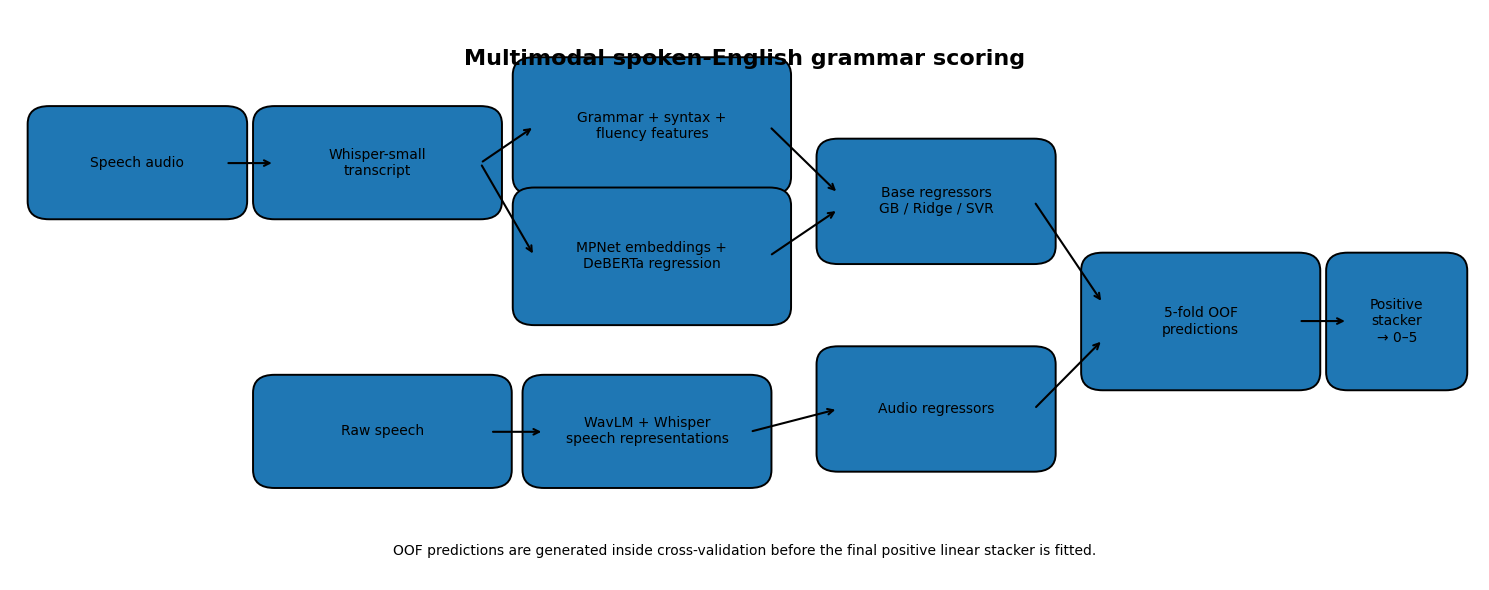

In [30]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ---- End-to-end pipeline diagram ----

fig, ax = plt.subplots(figsize=(15, 6))
ax.set_xlim(0, 15)
ax.set_ylim(0, 7)
ax.axis("off")

def box(x, y, w, h, label, fontsize=10):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.22",
        linewidth=1.4
    )
    ax.add_patch(patch)
    ax.text(x + w/2, y + h/2, label, ha="center", va="center",
            fontsize=fontsize, wrap=True)

def arrow(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", linewidth=1.5))

# Inputs
box(0.4, 4.65, 1.8, 0.95, "Speech audio")
box(2.7, 4.65, 2.1, 0.95, "Whisper-small\ntranscript")
box(5.35, 4.95, 2.4, 1.25, "Grammar + syntax +\nfluency features")
box(5.35, 3.35, 2.4, 1.25, "MPNet embeddings +\nDeBERTa regression")

box(2.7, 1.35, 2.2, 0.95, "Raw speech")
box(5.45, 1.35, 2.1, 0.95, "WavLM + Whisper\nspeech representations")

box(8.45, 4.10, 2.0, 1.10, "Base regressors\nGB / Ridge / SVR")
box(8.45, 1.55, 2.0, 1.10, "Audio regressors")

box(11.15, 2.55, 2.0, 1.25, "5-fold OOF\npredictions")
box(13.65, 2.55, 1.0, 1.25, "Positive\nstacker\n→ 0–5")

# Arrows
arrow(2.2, 5.12, 2.7, 5.12)
arrow(4.8, 5.12, 5.35, 5.57)
arrow(4.8, 5.12, 5.35, 3.98)
arrow(4.9, 1.82, 5.45, 1.82)
arrow(7.75, 5.57, 8.45, 4.75)
arrow(7.75, 3.98, 8.45, 4.55)
arrow(7.55, 1.82, 8.45, 2.10)
arrow(10.45, 4.65, 11.15, 3.40)
arrow(10.45, 2.10, 11.15, 2.95)
arrow(13.15, 3.18, 13.65, 3.18)

ax.text(7.5, 6.4, "Multimodal spoken-English grammar scoring", ha="center",
        va="center", fontsize=16, fontweight="bold")
ax.text(7.5, 0.35,
        "OOF predictions are generated inside cross-validation before the final positive linear stacker is fitted.",
        ha="center", va="center", fontsize=10)

plt.tight_layout()
plt.show()


## 3. Setup and Data Discovery

In [31]:
import os, re, math, time, zlib, hashlib, warnings, subprocess, sys
from collections import defaultdict
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

# ---- switches (set to False to skip heavy parts) ----
USE_WAVLM_BASE  = True   # ~10 min on a T4 (cached after first run)
USE_WHISPER_ENC = True   # ~5-8 min (estimate)
USE_WAVLM_LARGE = True   # ~20-30 min (estimate); set False for a faster run
USE_FINETUNE    = True   # DeBERTa seed 0, 5 folds, ~6 min (cached)
USE_EXTRA_FT    = True   # Fine-tuning stability experiment: DeBERTa seeds 1-2 + ELECTRA seeds 0-2 (~20-25 min on a T4, estimate)
WORK = "/kaggle/working"

import torch, librosa
GPU = torch.cuda.is_available()
DEVICE = 0 if GPU else -1
dev_str = "cuda" if GPU else "cpu"
print("GPU available:", GPU)
SR = 16000

GPU available: True


In [32]:
# ---- Locate competition files. Train and test folders contain files with the SAME names, so keep them per-folder. ----
ROOT = "/kaggle/input"
csv_paths, by_dir, input_files = {}, defaultdict(dict), {}
for dirpath, _, files in os.walk(ROOT):
    for f in files:
        full = os.path.join(dirpath, f)
        if f in ("train.csv", "test.csv", "sample_submission.csv"):
            csv_paths[f] = full
        elif f.lower().endswith(".wav"):
            by_dir[dirpath][f] = full
        else:
            input_files[f] = full          # candidate caches from attached previous runs
for d, m in by_dir.items():
    print(len(m), "wav |", d)

train = pd.read_csv(csv_paths["train.csv"])
test = pd.read_csv(csv_paths["test.csv"])

def best_dir(names, exclude=None):
    names = set(names)
    cands = [d for d in by_dir if d != exclude]
    return max(cands, key=lambda d: (len(names & set(by_dir[d])), -abs(len(by_dir[d]) - len(names))))

train_dir = best_dir(train.filename)
test_dir = best_dir(test.filename, exclude=train_dir)
print("train audio dir:", train_dir); print("test audio dir :", test_dir)
train["path"] = train.filename.map(by_dir[train_dir])
test["path"] = test.filename.map(by_dir[test_dir])
assert train.path.notna().all() and test.path.notna().all(), "audio files missing"

all_df = pd.concat([train.assign(split="train"), test.assign(split="test")], ignore_index=True)
tr_mask = (all_df.split == "train").values
te_mask = ~tr_mask
y = all_df.loc[tr_mask, "label"].values.astype(float)
print(all_df.shape, "| train:", tr_mask.sum(), "| test:", te_mask.sum())

# ---- cache helpers: look in /kaggle/working first, then in attached inputs ----
def cache_path(name):
    p = os.path.join(WORK, name)
    return p if os.path.exists(p) else input_files.get(name)

def load_csv_cache(name, n=None):
    p = cache_path(name)
    if p is None: return None
    try:
        d = pd.read_csv(p)
        return d if (n is None or len(d) == n) else None
    except Exception:
        return None

def load_npy_cache(name, n=None):
    p = cache_path(name)
    if p is None: return None
    try:
        a = np.load(p)
        return a if (n is None or a.shape[0] == n) else None
    except Exception:
        return None

216 wav | /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test
769 wav | /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train
train audio dir: /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train
test audio dir : /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test
(985, 4) | train: 769 | test: 216


## 3.1 Target Distribution and Data Overview

The dataset contains **769 labelled training recordings** and **216 test recordings**. The target is a continuous grammar score on a 0–5 scale.

The implementation also accounts for the fact that train and test recordings can share filenames by keeping file paths and cached transcript-derived artifacts keyed by split and filename.


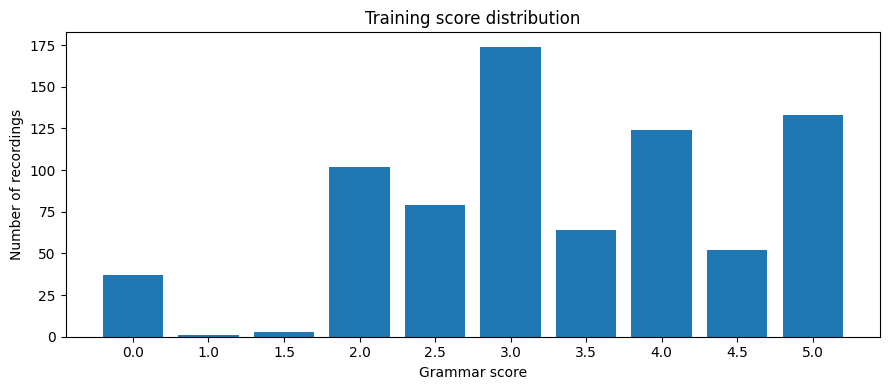

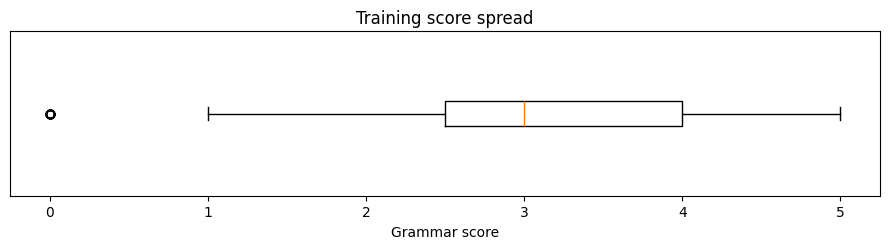

count    769.000
mean       3.313
std        1.239
min        0.000
25%        2.500
50%        3.000
75%        4.000
max        5.000
Name: label, dtype: float64
Baseline RMSE (predict the mean): 1.2382


In [33]:
# ---- Target distribution and simple baseline ----
label_counts = train["label"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(label_counts.index.astype(str), label_counts.values)
ax.set_xlabel("Grammar score")
ax.set_ylabel("Number of recordings")
ax.set_title("Training score distribution")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 2.6))
ax.boxplot(train["label"].values, vert=False)
ax.set_xlabel("Grammar score")
ax.set_yticks([])
ax.set_title("Training score spread")
plt.tight_layout()
plt.show()

BASE_RMSE = float(np.sqrt(((y - y.mean())**2).mean()))
print(train["label"].describe().round(3))
print("Baseline RMSE (predict the mean):", round(BASE_RMSE, 4))


## 4. Speech Transcription — Whisper

Each 45–60 second recording is transcribed using **Whisper-small** with native long-form decoding.

The transcript is deliberately not over-cleaned: fillers, repetitions and other disfluencies can contain useful information about fluency and grammatical control.

Transcript results are cached so the expensive ASR stage does not need to be repeated unnecessarily.


In [34]:
from transformers import AutoProcessor, WhisperForConditionalGeneration
TRANSCRIPT_CACHE = "transcripts_whisper_native_v3.csv"

def load_audio(path):
    y_, _ = librosa.load(path, sr=SR, mono=True)
    return y_

def transcribe_all(df, model_name="openai/whisper-small", batch_size=2):
    processor = AutoProcessor.from_pretrained(model_name)
    model = WhisperForConditionalGeneration.from_pretrained(
        model_name, dtype=torch.float16 if GPU else torch.float32, low_cpu_mem_usage=True).to(dev_str).eval()
    device = torch.device(dev_str)
    torch.manual_seed(SEED)
    out, paths = [], df["path"].tolist()
    for i in range(0, len(paths), batch_size):
        audios = [load_audio(p) for p in paths[i:i + batch_size]]
        inputs = processor(audios, sampling_rate=SR, return_tensors="pt", truncation=False,
                           padding="longest", return_attention_mask=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        if GPU: inputs["input_features"] = inputs["input_features"].to(dtype=torch.float16)
        with torch.inference_mode():
            ids = model.generate(**inputs, language="en", task="transcribe", return_timestamps=True,
                                 condition_on_prev_tokens=True, compression_ratio_threshold=1.35,
                                 logprob_threshold=-1.0, no_speech_threshold=0.6,
                                 temperature=(0.0, 0.2, 0.4, 0.6, 0.8, 1.0))
        out.extend(t.strip() for t in processor.batch_decode(ids, skip_special_tokens=True, clean_up_tokenization_spaces=False))
        if (i // batch_size) % 25 == 0: print(f"{min(i + batch_size, len(paths))}/{len(paths)}", end=" | ", flush=True)
    del model, processor
    if GPU: torch.cuda.empty_cache()
    return out

tr_cache = load_csv_cache(TRANSCRIPT_CACHE, len(all_df))
if tr_cache is not None and {"split", "filename", "transcript"}.issubset(tr_cache.columns):
    print("Using cached transcripts:", cache_path(TRANSCRIPT_CACHE))
    all_df = all_df.merge(tr_cache.fillna("")[["split", "filename", "transcript"]], on=["split", "filename"], how="left", validate="one_to_one")
    assert len(all_df) == tr_mask.size and all_df.transcript.notna().all(), "transcript merge failed"
else:
    t0 = time.time()
    all_df["transcript"] = transcribe_all(all_df)
    all_df[["split", "filename", "transcript"]].to_csv(os.path.join(WORK, TRANSCRIPT_CACHE), index=False)
    print(f"\nWhisper ASR done in {(time.time()-t0)/60:.1f} min")
all_df["transcript"] = all_df["transcript"].fillna("")
assert (all_df.split.values == np.where(tr_mask, "train", "test")).all()
TXT_HASH = hashlib.md5("\n".join(all_df.transcript).encode("utf-8")).hexdigest()[:8]   # keys all transcript-dependent caches
print("transcript fingerprint:", TXT_HASH)
all_df.sample(4, random_state=SEED)[["split", "filename", "label", "transcript"]]

Using cached transcripts: /kaggle/input/datasets/piyushshx/transcriptsv4/transcripts_whisper_native_v3.csv
transcript fingerprint: fe6bc6bc


,split,filename,label,transcript
613,train,audio_25.wav,3.0,we went to a resort last summer with my family...
451,train,audio_577.wav,4.0,So my favorite plus is nature. The best place ...
731,train,audio_86.wav,2.0,"Yeah, there was a scene in the crowded market ..."
436,train,audio_237.wav,3.0,The playground is composed of students who are...


## 4.1 Example Input: Audio Signal + Whisper Transcript

A single clip helps connect the engineering pipeline to the actual data: the waveform represents the acoustic signal, while the transcript is the input used by the linguistic and text models.


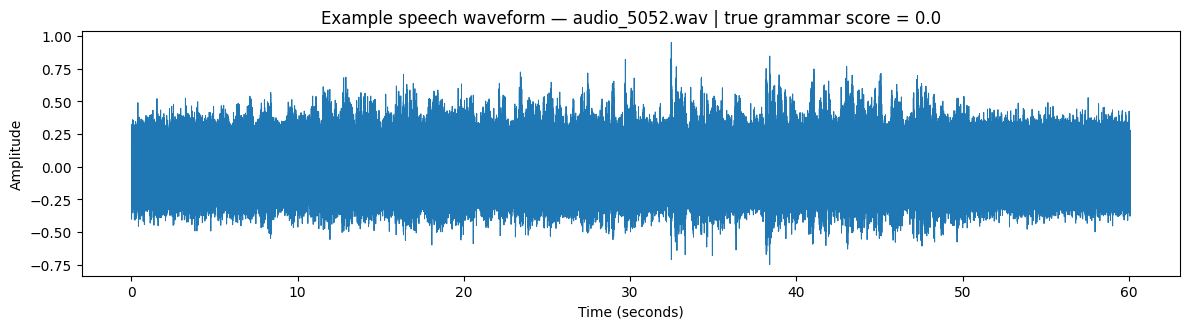

Whisper transcript excerpt:
I want to make a new tour of my company with my company. I really want to be my own dad someday. I try to welcome dad and get advice from my husband. Hopefully I will catch good soon and improve myself. I will talk about my future and after I do it I will come to my company.


In [35]:
import librosa
import matplotlib.pyplot as plt

# ---- One representative training clip: waveform + transcript excerpt ----
# This cell is intentionally based on all_df so the split is explicit and
# the visualization remains safe even when train/test filenames overlap.
if "all_df" not in globals():
    raise RuntimeError(
        "Please run the notebook from the beginning through the data discovery "
        "and Whisper transcription sections before running this visualization."
    )

train_view = all_df.loc[all_df["split"] == "train"].reset_index(drop=True)
sample_row = train_view.iloc[len(train_view) // 2]

audio_y, _ = librosa.load(sample_row["path"], sr=SR, mono=True)
time_axis = np.arange(len(audio_y)) / SR

fig, ax = plt.subplots(figsize=(12, 3.4))
ax.plot(time_axis, audio_y, linewidth=0.7)
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Amplitude")
ax.set_title(
    f"Example speech waveform — {sample_row['filename']} | "
    f"true grammar score = {sample_row['label']:.1f}"
)
plt.tight_layout()
plt.show()

sample_transcript = str(sample_row["transcript"])
print("Whisper transcript excerpt:")
print(
    sample_transcript[:700] +
    ("..." if len(sample_transcript) > 700 else "")
)


## 5. Linguistic and Grammar Feature Engineering

The transcript is converted into an interpretable feature set covering several dimensions of spoken-language quality:

- grammar-error density using **LanguageTool**
- syntactic structure using **spaCy**
- sentence length and complexity
- vocabulary richness and lexical diversity
- repetition, fillers and disfluency
- punctuation and sentence-completion patterns
- language-model perplexity using **GPT-2**

These features complement neural embeddings by providing explicit, interpretable signals related to grammar and fluency.


In [36]:
# ---- Core handcrafted features ----
FILLERS = {"um", "uh", "er", "ah", "erm", "hmm", "mm", "like"}
SUBORD = {"because", "although", "though", "while", "whereas", "since", "unless", "if", "when", "which", "who", "whom",
          "whose", "that", "where", "however", "therefore", "moreover", "furthermore", "but", "so", "and", "or"}
AUX = {"is", "are", "was", "were", "be", "been", "being", "am", "have", "has", "had", "do", "does", "did",
       "will", "would", "can", "could", "should", "may", "might", "must"}

def split_sentences(text):
    s = [x.strip() for x in re.split(r"(?<=[.!?])\s+", text) if x.strip()]
    return s if s else ([text] if text.strip() else [])

def text_features(text):
    words = re.findall(r"[A-Za-z']+", text.lower()); n = len(words)
    sents = split_sentences(text)
    slen = np.array([len(re.findall(r"[A-Za-z']+", s)) for s in sents]) if sents else np.array([0])
    reps = sum(1 for a, b in zip(words, words[1:]) if a == b)
    tri = list(zip(words, words[1:], words[2:])); raw = text.encode("utf-8")
    run, best_run = 1, 1
    for a, b in zip(words, words[1:]):
        run = run + 1 if a == b else 1; best_run = max(best_run, run)
    return {
        "n_words": n, "n_unique": len(set(words)), "ttr": len(set(words)) / n if n else 0,
        "n_sents": len(sents), "avg_sent_len": slen.mean(), "std_sent_len": slen.std(), "max_sent_len": slen.max(),
        "short_sent_frac": (slen < 4).mean() if len(slen) else 1,
        "avg_word_len": np.mean([len(w) for w in words]) if n else 0,
        "long_word_frac": np.mean([len(w) >= 7 for w in words]) if n else 0,
        "filler_rate": sum(w in FILLERS for w in words) / n if n else 0,
        "repeat_rate": reps / n if n else 0, "max_word_run": best_run,
        "subord_rate": sum(w in SUBORD for w in words) / n if n else 0,
        "aux_rate": sum(w in AUX for w in words) / n if n else 0,
        "comma_rate": text.count(",") / n if n else 0,
        "ends_with_punct": float(text.strip()[-1:] in ".!?") if text.strip() else 0,
        "lower_start_sents": np.mean([s[0].islower() for s in sents]) if sents else 0,
        "compress_ratio": len(raw) / max(len(zlib.compress(raw)), 1) if raw else 0,
        "trigram_repeat": 1 - len(set(tri)) / len(tri) if tri else 0,
    }

def audio_features(path):
    y_ = load_audio(path); dur = len(y_) / SR
    iv = librosa.effects.split(y_, top_db=30)
    speech = sum(e - s for s, e in iv) / SR
    return {"duration": dur, "speech_time": speech, "pause_ratio": 1 - speech / dur if dur else 0, "n_segments": len(iv)}

BASIC = load_csv_cache(f"feats_basic_{TXT_HASH}.csv", len(all_df))
if BASIC is None:
    t0 = time.time()
    TF = pd.DataFrame([text_features(t) for t in all_df.transcript])
    AF = pd.DataFrame([audio_features(p) for p in all_df.path])
    AF["wps"] = TF["n_words"] / AF["speech_time"].clip(lower=1)
    BASIC = pd.concat([TF, AF], axis=1); BASIC.to_csv(os.path.join(WORK, f"feats_basic_{TXT_HASH}.csv"), index=False)
    print(f"Basic features done in {time.time()-t0:.0f}s", BASIC.shape)
else:
    print("loaded cached basic features")

# ---- GPT-2 perplexity features ----
PF = load_csv_cache(f"feats_ppl_{TXT_HASH}.csv", len(all_df))
if PF is None:
    from transformers import AutoTokenizer, AutoModelForCausalLM
    gpt_tok = AutoTokenizer.from_pretrained("gpt2")
    gpt = AutoModelForCausalLM.from_pretrained("gpt2").to(dev_str).eval()

    @torch.no_grad()
    def sent_nll(sent):
        ids = gpt_tok(gpt_tok.bos_token + sent, return_tensors="pt", truncation=True, max_length=128).input_ids.to(gpt.device)
        if ids.shape[1] < 2: return np.nan
        return gpt(ids, labels=ids).loss.item()

    def ppl_features(text):
        nll = [x for x in (sent_nll(s) for s in split_sentences(text)) if not np.isnan(x)]
        if not nll: return {"nll_mean": np.nan, "nll_max": np.nan, "nll_std": np.nan, "nll_p75": np.nan}
        return {"nll_mean": np.mean(nll), "nll_max": np.max(nll), "nll_std": np.std(nll), "nll_p75": np.percentile(nll, 75)}

    t0 = time.time()
    PF = pd.DataFrame([ppl_features(t) for t in all_df.transcript])
    PF.to_csv(os.path.join(WORK, f"feats_ppl_{TXT_HASH}.csv"), index=False)
    print(f"Perplexity features done in {time.time()-t0:.0f}s")
    del gpt
    if GPU: torch.cuda.empty_cache()
else:
    print("loaded cached perplexity features")

# ---- LanguageTool grammar errors + spaCy syntax ----
from tqdm.auto import tqdm

LT_F = load_csv_cache(f"feats_lt_{TXT_HASH}.csv", len(all_df))
if LT_F is None:
    try:
        t0 = time.time()
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "language_tool_python"], check=True, timeout=300)
        import language_tool_python
        tool = language_tool_python.LanguageTool("en-US")
        def lt_feats(t):
            m = tool.check(t) if t.strip() else []
            n = max(len(t.split()), 1)
            rid = lambda x: str(getattr(x, "rule_id", getattr(x, "ruleId", "")))
            cat = lambda x: str(getattr(x, "category", ""))
            grammar = [x for x in m if cat(x) in ("GRAMMAR", "TYPOS", "PUNCTUATION") or "GRAMMAR" in rid(x)]
            return {"lt_errors": len(m), "lt_err_per_word": len(m) / n, "lt_grammar_err": len(grammar), "lt_grammar_per_word": len(grammar) / n}
        LT_F = pd.DataFrame([lt_feats(t) for t in tqdm(all_df.transcript, desc="LanguageTool")])
        tool.close()
        LT_F.to_csv(os.path.join(WORK, f"feats_lt_{TXT_HASH}.csv"), index=False)
        print(f"LanguageTool done in {time.time()-t0:.0f}s", LT_F.shape)
    except Exception as e:
        print("LanguageTool skipped:", repr(e)[:200]); LT_F = pd.DataFrame(index=all_df.index)
else:
    print("loaded cached LanguageTool features")

SP_F = load_csv_cache(f"feats_sp_{TXT_HASH}.csv", len(all_df))
if SP_F is None:
    try:
        t0 = time.time()
        import spacy
        try: nlp = spacy.load("en_core_web_sm")
        except OSError:
            subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True, timeout=300)
            nlp = spacy.load("en_core_web_sm")
        def depth(tok):
            d = 0
            while tok.head.i != tok.i:
                tok = tok.head; d += 1
            return d
        def sp_feats(doc):
            sents = list(doc.sents); n = max(len(doc), 1)
            no_verb = np.mean([not any(tk.pos_ in ("VERB", "AUX") for tk in s) for s in sents]) if sents else 1
            no_subj = np.mean([not any(tk.dep_ in ("nsubj", "nsubjpass", "expl") for tk in s) for s in sents]) if sents else 1
            return {"sp_no_verb_sent": no_verb, "sp_no_subj_sent": no_subj,
                    "sp_clause_rate": sum(tk.dep_ in ("advcl", "ccomp", "relcl", "acl", "xcomp", "csubj") for tk in doc) / n,
                    "sp_max_depth": max([depth(tk) for tk in doc], default=0),
                    "sp_pos_variety": len({tk.pos_ for tk in doc}),
                    "sp_tense_variety": len({tk.morph.get("Tense")[0] for tk in doc if tk.morph.get("Tense")})}
        docs = nlp.pipe(all_df.transcript.tolist(), batch_size=32, disable=["ner", "lemmatizer"])
        SP_F = pd.DataFrame([sp_feats(d) for d in tqdm(docs, total=len(all_df), desc="spaCy")])
        SP_F.to_csv(os.path.join(WORK, f"feats_sp_{TXT_HASH}.csv"), index=False)
        print(f"spaCy done in {time.time()-t0:.0f}s", SP_F.shape)
    except Exception as e:
        print("spaCy skipped:", repr(e)[:200]); SP_F = pd.DataFrame(index=all_df.index)
else:
    print("loaded cached spaCy features")

FEATS = pd.concat([BASIC.reset_index(drop=True), PF.reset_index(drop=True), LT_F.reset_index(drop=True), SP_F.reset_index(drop=True)], axis=1)
FEATS = FEATS.replace([np.inf, -np.inf], np.nan)

# ============================================================
# Focused grammar / syntax / disfluency features
# ============================================================
V10_EXTRA_CACHE = f"feats_v10_extra_{TXT_HASH}.csv"
V10_EXTRA = load_csv_cache(V10_EXTRA_CACHE, len(all_df))

if V10_EXTRA is None:
    t0 = time.time()
    rows = []
    correction_markers = ("i mean", "what i mean", "actually", "sorry", "rather", "let me rephrase")

    def lexical_grammar_features(text):
        words = re.findall(r"[A-Za-z']+", text.lower())
        n = len(words)
        sents = split_sentences(text)
        slens = np.array([len(re.findall(r"[A-Za-z']+", s)) for s in sents], dtype=float) if sents else np.array([0.0])
        bigrams = list(zip(words, words[1:]))

        filler_sent_frac = (
            np.mean([any(w in FILLERS for w in re.findall(r"[A-Za-z']+", s.lower())) for s in sents])
            if sents else 0.0
        )
        repeat_bigram_rate = (
            (len(bigrams) - len(set(bigrams))) / max(len(bigrams), 1)
            if bigrams else 0.0
        )
        correction_count = sum(text.lower().count(m) for m in correction_markers)

        return {
            "v10_sent_len_cv": float(slens.std() / max(slens.mean(), 1.0)),
            "v10_sent_len_p90": float(np.percentile(slens, 90)),
            "v10_word_len_std": float(np.std([len(w) for w in words])) if words else 0.0,
            "v10_filler_sent_frac": float(filler_sent_frac),
            "v10_repeat_bigram_rate": float(repeat_bigram_rate),
            "v10_correction_marker_rate": float(correction_count / max(n, 1)),
            "v10_grammar_marker_rate": float(sum(w in {"although", "because", "whereas", "unless", "while"} for w in words) / max(n, 1)),
        }

    for t in tqdm(all_df.transcript.tolist(), desc="lexical/grammar features"):
        rows.append(lexical_grammar_features(t))
    V10_EXTRA = pd.DataFrame(rows)
    V10_EXTRA.to_csv(os.path.join(WORK, V10_EXTRA_CACHE), index=False)
    print(f"lexical/grammar features done in {time.time()-t0:.1f}s", V10_EXTRA.shape)

# More structured syntax features. This cache is separate so a rerun never has
# to rebuild the expensive Whisper/GPT-2/LanguageTool branches.
V10_SP_CACHE = f"feats_v10_spacy_{TXT_HASH}.csv"
V10_SP = load_csv_cache(V10_SP_CACHE, len(all_df))

if V10_SP is None:
    try:
        import spacy
        if "nlp" not in globals():
            try: nlp = spacy.load("en_core_web_sm")
            except OSError:
                subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True, timeout=300)
                nlp = spacy.load("en_core_web_sm")

        def depth(tok):
            d = 0
            while tok.head.i != tok.i:
                tok = tok.head; d += 1
            return d

        def advanced_spacy_features(doc):
            toks = [t for t in doc if not t.is_space]
            alpha = [t for t in toks if t.is_alpha]
            n = max(len(alpha), 1)
            sents = list(doc.sents)

            dep_depths = np.array([depth(t) for t in toks], dtype=float) if toks else np.array([0.0])
            clauses = sum(t.dep_ in ("advcl", "ccomp", "relcl", "acl", "xcomp", "csubj") for t in toks)
            roots = sum(t.dep_ == "ROOT" for t in toks)
            frag = sum(
                (not any(t.pos_ in ("VERB", "AUX") for t in s))
                and (not any(t.dep_ in ("nsubj", "nsubjpass", "expl") for t in s))
                for s in sents
            )

            def pos_rate(pos):
                return sum(t.pos_ == pos for t in alpha) / n

            return {
                "v10_sp_avg_depth": float(dep_depths.mean()),
                "v10_sp_depth_p75": float(np.percentile(dep_depths, 75)),
                "v10_sp_depth_std": float(dep_depths.std()),
                "v10_sp_clause_per_sent": float(clauses / max(len(sents), 1)),
                "v10_sp_fragment_rate": float(frag / max(len(sents), 1)),
                "v10_sp_verb_rate": float((sum(t.pos_ in ("VERB", "AUX") for t in alpha)) / n),
                "v10_sp_noun_rate": float(pos_rate("NOUN")),
                "v10_sp_pronoun_rate": float(pos_rate("PRON")),
                "v10_sp_adj_rate": float(pos_rate("ADJ")),
                "v10_sp_adv_rate": float(pos_rate("ADV")),
                "v10_sp_prep_rate": float(pos_rate("ADP")),
                "v10_sp_conj_rate": float(pos_rate("CCONJ") + pos_rate("SCONJ")),
                "v10_sp_dep_variety": float(len({t.dep_ for t in toks})),
                "v10_sp_root_rate": float(roots / n),
            }

        docs = nlp.pipe(all_df.transcript.tolist(), batch_size=32, disable=["ner", "lemmatizer"])
        V10_SP = pd.DataFrame([advanced_spacy_features(d) for d in tqdm(docs, total=len(all_df), desc="spaCy syntax features")])
        V10_SP.to_csv(os.path.join(WORK, V10_SP_CACHE), index=False)
        print(f"spaCy syntax features done in {(time.time()-t0)/60:.1f} min", V10_SP.shape)
    except Exception as e:
        print("spaCy syntax features skipped:", repr(e)[:250])
        V10_SP = pd.DataFrame(index=all_df.index)

V10_EXTRA_FULL = pd.concat([V10_EXTRA.reset_index(drop=True), V10_SP.reset_index(drop=True)], axis=1)

# Derived error-density features use only already-computed LanguageTool counts.
if len(LT_F.columns):
    n_words = BASIC["n_words"].replace(0, np.nan)
    n_sents = BASIC["n_sents"].replace(0, np.nan)
    lt_plus = pd.DataFrame({
        "v10_lt_errors_per_sentence": LT_F["lt_errors"] / n_sents,
        "v10_lt_grammar_per_sentence": LT_F["lt_grammar_err"] / n_sents,
        "v10_lt_non_grammar_per_word": (LT_F["lt_errors"] - LT_F["lt_grammar_err"]) / n_words,
        "v10_lt_errors_per_100_words": 100.0 * LT_F["lt_errors"] / n_words,
        "v10_lt_grammar_per_100_words": 100.0 * LT_F["lt_grammar_err"] / n_words,
    })
    V10_EXTRA_FULL = pd.concat([V10_EXTRA_FULL.reset_index(drop=True), lt_plus.reset_index(drop=True)], axis=1)

V10_EXTRA_FULL = V10_EXTRA_FULL.replace([np.inf, -np.inf], np.nan)
FEATS_ENGINEERED = pd.concat([FEATS.reset_index(drop=True), V10_EXTRA_FULL.reset_index(drop=True)], axis=1)
print("Baseline handcrafted features :", FEATS.shape)
print("New V10 features              :", V10_EXTRA_FULL.shape)
print("Engineered feature matrix     :", FEATS_ENGINEERED.shape)

# Supervised diagnostics are for inspection only. They are never used globally
# to select features; fold-safe selection below recomputes correlations inside
# each training fold.
def train_target_corr_table(F):
    tmp = F.copy().astype(float)
    vals = {}
    for c in tmp.columns:
        x = tmp[c].copy()
        if x.isna().all() or x.nunique(dropna=True) <= 1:
            vals[c] = np.nan
            continue
        x = x.fillna(x.median())
        vals[c] = float(np.corrcoef(x.loc[tr_mask], y)[0,1])
    return pd.Series(vals).sort_values(key=lambda s: s.abs(), ascending=False)

print("\nTop V10 features by train-only Pearson correlation:")
display(train_target_corr_table(V10_EXTRA_FULL).head(15).to_frame("target_corr"))

def report_redundant_pairs(F, threshold=0.90):
    X = F.loc[tr_mask].astype(float).copy()
    X = X.loc[:, X.nunique(dropna=False) > 1]
    X = X.fillna(X.median())
    C = X.corr().abs()
    upper = C.where(np.triu(np.ones(C.shape), k=1).astype(bool))
    pairs = []
    for col in upper.columns:
        for row in upper.index:
            v = upper.loc[row, col]
            if pd.notna(v) and v >= threshold:
                pairs.append((row, col, float(v)))
    return pd.DataFrame(pairs, columns=["feature_1", "feature_2", "abs_corr"]).sort_values("abs_corr", ascending=False)

red_pairs = report_redundant_pairs(FEATS_ENGINEERED, threshold=0.90)
print(f"\nHighly correlated train-feature pairs (|r| >= 0.90): {len(red_pairs)}")
display(red_pairs.head(20))

loaded cached basic features
loaded cached perplexity features
loaded cached LanguageTool features
loaded cached spaCy features
Baseline handcrafted features : (985, 39)
New V10 features              : (985, 26)
Engineered feature matrix     : (985, 65)

Top V10 features by train-only Pearson correlation:


,target_corr
v10_sp_dep_variety,0.345555
v10_repeat_bigram_rate,-0.233647
v10_word_len_std,0.221629
v10_lt_errors_per_100_words,-0.194809
v10_lt_grammar_per_100_words,-0.162022
v10_lt_non_grammar_per_word,-0.123602
v10_sp_adj_rate,0.121400
v10_sp_adv_rate,0.118283
v10_sent_len_cv,0.116419
v10_sp_depth_std,0.107790



Highly correlated train-feature pairs (|r| >= 0.90): 19


,feature_1,feature_2,abs_corr
17,lt_grammar_per_word,v10_lt_grammar_per_100_words,0.999437
13,lt_err_per_word,v10_lt_errors_per_100_words,0.999227
8,max_sent_len,v10_sent_len_p90,0.974249
11,v10_lt_errors_per_sentence,v10_lt_grammar_per_sentence,0.971324
7,avg_sent_len,v10_sent_len_p90,0.962799
9,v10_sp_avg_depth,v10_sp_depth_p75,0.954154
10,sp_max_depth,v10_sp_depth_std,0.947406
2,nll_mean,nll_p75,0.930038
6,lt_grammar_err,lt_grammar_per_word,0.927670
16,lt_grammar_err,v10_lt_grammar_per_100_words,0.927027


## 5.1 Interpretable Feature Signals

Before the high-dimensional embeddings are used, the engineered features provide an interpretable view of the problem. The chart below shows the strongest **descriptive** correlations with the training score. These correlations are for analysis and interpretation; they are not used as a substitute for cross-validation.


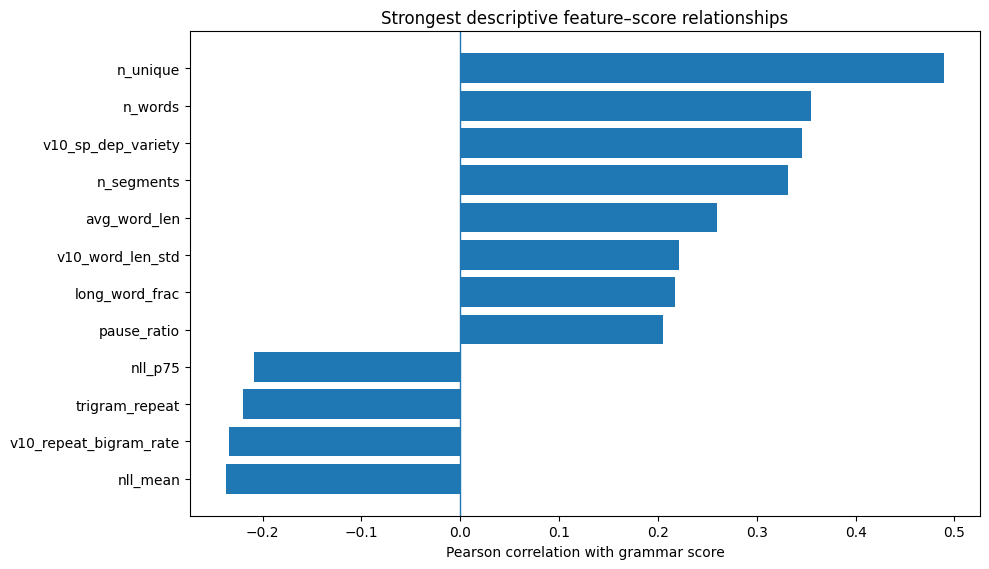

In [37]:
import matplotlib.pyplot as plt
# ---- Strongest descriptive correlations among engineered features ----
Xf = FEATS_ENGINEERED.loc[tr_mask].copy()
ys = pd.Series(y, index=Xf.index, name="label")

numeric_cols = Xf.select_dtypes(include=[np.number]).columns
corr = Xf[numeric_cols].corrwith(ys).dropna()
top_corr = corr.reindex(corr.abs().sort_values(ascending=False).head(12).index).sort_values()

fig, ax = plt.subplots(figsize=(10, 5.8))
ax.barh(top_corr.index, top_corr.values)
ax.axvline(0, linewidth=1)
ax.set_xlabel("Pearson correlation with grammar score")
ax.set_title("Strongest descriptive feature–score relationships")
plt.tight_layout()
plt.show()


## 6. Text Representation

**MPNet** embeddings capture semantic and contextual information from the transcript.

A task-specific **DeBERTa-v3-base** regression model is also fine-tuned directly on the transcripts. Because the dataset is relatively small, multiple training seeds are evaluated and the strongest stable configuration is considered for the final ensemble.


In [38]:
from sentence_transformers import SentenceTransformer
texts = all_df.transcript.tolist()
EMB_MPNET = SentenceTransformer("sentence-transformers/all-mpnet-base-v2", device=dev_str).encode(
    texts, batch_size=32, normalize_embeddings=True, show_progress_bar=False)
print("Text embeddings:", EMB_MPNET.shape)
if GPU: torch.cuda.empty_cache()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Text embeddings: (985, 768)


In [39]:
from transformers import AutoFeatureExtractor, AutoModel

def extract_ssl(model_name, layers, cache_name, desc):
    # mean+std pooled hidden states of a self-supervised speech model (WavLM family)
    cached = load_npy_cache(cache_name, len(all_df))
    if cached is not None:
        print(f"loaded cached {desc}:", cached.shape); return cached
    try:
        fe = AutoFeatureExtractor.from_pretrained(model_name)
        model = AutoModel.from_pretrained(model_name).to(dev_str).eval()
        rows, t0 = [], time.time()
        with torch.inference_mode():
            for p in tqdm(all_df.path, desc=desc):
                wav = load_audio(p)[: SR * 70]
                inp = fe(wav, sampling_rate=SR, return_tensors="pt").input_values.to(dev_str)
                if GPU:
                    with torch.autocast("cuda", dtype=torch.float16):
                        hs = model(inp, output_hidden_states=True).hidden_states
                else:
                    hs = model(inp, output_hidden_states=True).hidden_states
                pooled = []
                for l in layers:
                    h = hs[l].float().squeeze(0)
                    pooled += [h.mean(0), h.std(0, unbiased=False)]
                rows.append(torch.cat(pooled).cpu().numpy())
        E = np.stack(rows).astype(np.float32); np.save(os.path.join(WORK, cache_name), E)
        print(f"{desc} done in {(time.time()-t0)/60:.1f} min", E.shape)
        del model, fe
        if GPU: torch.cuda.empty_cache()
        return E
    except Exception as e:
        print(f"{desc} skipped:", repr(e)[:300]); return None

EMB_WAVLM_BASE = extract_ssl("microsoft/wavlm-base-plus", (4, 8, 12), "emb_wavlm_v3_meanstd.npy", "WavLM-base") if USE_WAVLM_BASE else None

loaded cached WavLM-base: (985, 4608)


In [40]:
def extract_whisper_encoder(cache_name="emb_whisper_enc_v4.npy", layers=(6, 9, 12)):
    cached = load_npy_cache(cache_name, len(all_df))
    if cached is not None:
        print("loaded cached Whisper-encoder embeddings:", cached.shape); return cached
    try:
        from transformers import WhisperFeatureExtractor, WhisperModel
        wfe = WhisperFeatureExtractor.from_pretrained("openai/whisper-small")
        enc = WhisperModel.from_pretrained("openai/whisper-small").encoder.to(dev_str).eval()
        CH, rows, t0 = SR * 30, [], time.time()
        with torch.inference_mode():
            for p in tqdm(all_df.path, desc="Whisper encoder"):
                wav = load_audio(p)
                chunks = [wav[i:i + CH] for i in range(0, len(wav), CH)]
                chunks = [c for c in chunks if len(c) >= SR] or [wav]            # drop a <1 s tail
                feats = wfe(chunks, sampling_rate=SR, return_tensors="pt").input_features.to(dev_str)
                if GPU:
                    with torch.autocast("cuda", dtype=torch.float16):
                        hs = enc(feats, output_hidden_states=True).hidden_states
                else:
                    hs = enc(feats, output_hidden_states=True).hidden_states
                valid = [max(1, min(1500, math.ceil(len(c) / 320))) for c in chunks]   # 50 encoder frames per second
                pooled = []
                for l in layers:
                    h = torch.cat([hs[l][j, :v].float() for j, v in enumerate(valid)], dim=0)   # valid frames only
                    pooled += [h.mean(0), h.std(0, unbiased=False)]
                rows.append(torch.cat(pooled).cpu().numpy())
        E = np.stack(rows).astype(np.float32); np.save(os.path.join(WORK, cache_name), E)
        print(f"Whisper-encoder embeddings done in {(time.time()-t0)/60:.1f} min", E.shape)
        del enc, wfe
        if GPU: torch.cuda.empty_cache()
        return E
    except Exception as e:
        print("Whisper-encoder embeddings skipped:", repr(e)[:300]); return None

EMB_WHISPER_ENC = extract_whisper_encoder() if USE_WHISPER_ENC else None

loaded cached Whisper-encoder embeddings: (985, 4608)


In [41]:
EMB_WAVLM_LARGE = extract_ssl("microsoft/wavlm-large", (8, 16, 24), "emb_wavlm_large_v4.npy", "WavLM-large") if USE_WAVLM_LARGE else None

AUDIO_VIEWS = {k: v for k, v in {"wavlm_base": EMB_WAVLM_BASE, "whisper_enc": EMB_WHISPER_ENC, "wavlm_large": EMB_WAVLM_LARGE}.items() if v is not None}
print("Audio views available:", {k: v.shape for k, v in AUDIO_VIEWS.items()})
assert AUDIO_VIEWS, "no audio view could be computed"

loaded cached WavLM-large: (985, 6144)
Audio views available: {'wavlm_base': (985, 4608), 'whisper_enc': (985, 4608), 'wavlm_large': (985, 6144)}


## 7. Cross-Validation and Base Models

The supervised models use **5-fold cross-validation**. Every base model generates out-of-fold (OOF) predictions so the ensemble can be trained without using a model's own training predictions as validation evidence.

The audio, text and multimodal branches are evaluated separately before their predictions are combined.


In [42]:
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

K = 5
n_tr = int(tr_mask.sum())
folds = list(StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED).split(
    np.zeros(n_tr), (y * 2).astype(int)
))

def rmse(a, b):
    return float(np.sqrt(mean_squared_error(a, b)))

def score(a, b):
    b = np.clip(b, 0, 5)
    return rmse(a, b), float(pearsonr(a, b)[0])

ALPHAS_AUDIO = np.logspace(2, 6, 14)

# -------------------------
# Core audio/text heads
# -------------------------
FIXED_BASE = {}

def run_fixed(name, make_model, X, group):
    Xtr, Xte = X[tr_mask], X[te_mask]
    oof, trp, tep = np.zeros(n_tr), np.zeros(n_tr), np.zeros(len(Xte))
    for a, b in folds:
        m = make_model().fit(Xtr[a], y[a])
        oof[b] = m.predict(Xtr[b])
        trp += m.predict(Xtr) / K
        tep += m.predict(Xte) / K
    FIXED_BASE[name] = {"oof": oof, "train": trp, "test": tep, "group": group}
    r, p = score(y, oof)
    print(f"{name:42s} CV RMSE={r:.4f}  Pearson={p:.4f}")
    return r

# MPNet-only SVR is not affected by handcrafted features and remains fixed.
run_fixed(
    "SVR - MPNet text emb",
    lambda: make_pipeline(StandardScaler(), SVR(C=3.0, epsilon=0.15, gamma="scale")),
    EMB_MPNET, "text"
)

for view, E in AUDIO_VIEWS.items():
    run_fixed(
        f"Ridge - {view} emb",
        lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS_AUDIO)),
        E, f"audio_{view}"
    )
    run_fixed(
        f"SVR - {view} emb",
        lambda: make_pipeline(StandardScaler(), SVR(C=3.0, epsilon=0.15, gamma="scale")),
        E, f"audio_{view}"
    )

if len(AUDIO_VIEWS) >= 2:
    blocks = list(AUDIO_VIEWS.values())
    dims = [b.shape[1] for b in blocks]
    X_audio_all = np.hstack(blocks)
    edges = np.cumsum([0] + dims)

    def make_all_audio_ridge():
        ct = ColumnTransformer([
            (f"v{i}",
             make_pipeline(
                 StandardScaler(),
                 FunctionTransformer(lambda X, s=math.sqrt(max(dims) / d): X * s)
             ),
             slice(int(edges[i]), int(edges[i + 1])))
            for i, d in enumerate(dims)
        ])
        return make_pipeline(ct, RidgeCV(alphas=ALPHAS_AUDIO))

    run_fixed("Ridge - all audio views", make_all_audio_ridge, X_audio_all, "audio_combined")

SVR - MPNet text emb                       CV RMSE=0.9848  Pearson=0.6068
Ridge - wavlm_base emb                     CV RMSE=0.5469  Pearson=0.8973
SVR - wavlm_base emb                       CV RMSE=0.5511  Pearson=0.8971
Ridge - whisper_enc emb                    CV RMSE=0.5446  Pearson=0.8988
SVR - whisper_enc emb                      CV RMSE=0.5478  Pearson=0.9019
Ridge - wavlm_large emb                    CV RMSE=0.5114  Pearson=0.9109
SVR - wavlm_large emb                      CV RMSE=0.5295  Pearson=0.9072
Ridge - all audio views                    CV RMSE=0.5156  Pearson=0.9094


In [43]:
# ============================================================
# Controlled feature variants
# ============================================================

FEATURE_VARIANTS = {"V10-B engineered": FEATS_ENGINEERED.copy()}   # alternate feature variants are not repeated

def select_fold_features(X_train_df, y_train, threshold=0.92, var_eps=1e-10):
    """
    Leakage-safe feature pruning performed independently inside each CV fold.
    1) remove near-zero variance features;
    2) for highly correlated pairs, keep the feature with stronger absolute
       training-fold target correlation.
    """
    X = X_train_df.astype(float).copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.loc[:, X.nunique(dropna=False) > 1]
    if X.shape[1] == 0:
        return []

    X_imp = X.fillna(X.median())
    variances = X_imp.var(axis=0)
    keep = variances[variances > var_eps].index.tolist()
    if not keep:
        return []

    X_imp = X_imp[keep]
    target_corr = {}
    y_arr = np.asarray(y_train, dtype=float)
    for c in keep:
        xc = X_imp[c].to_numpy(dtype=float)
        target_corr[c] = abs(float(np.corrcoef(xc, y_arr)[0, 1])) if np.std(xc) > 0 and np.std(y_arr) > 0 else 0.0

    corr = X_imp.corr().abs()
    selected = []
    for c in keep:
        conflict = [s for s in selected if pd.notna(corr.loc[s, c]) and corr.loc[s, c] >= threshold]
        if not conflict:
            selected.append(c)
        else:
            # Compare against the strongest conflicting selected feature.
            strongest = max(conflict, key=lambda s: corr.loc[s, c])
            if target_corr[c] > target_corr[strongest]:
                selected.remove(strongest)
                selected.append(c)
    return selected


def make_multimodal_ridge_for_dim(f_dim, audio_dim, total_dim, w_audio=0.4, w_text=3.0):
    def factory():
        pre = ColumnTransformer([
            ("features", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()),
             slice(0, f_dim)),
            ("audio", make_pipeline(
                SimpleImputer(strategy="median"), StandardScaler(),
                FunctionTransformer(lambda X, w=w_audio: X * w)),
             slice(f_dim, f_dim + audio_dim)),
            ("text", FunctionTransformer(lambda X, w=w_text: X * w),
             slice(f_dim + audio_dim, total_dim)),
        ])
        return make_pipeline(pre, RidgeCV(alphas=np.logspace(1, 4, 12)))
    return factory

def stack_cv(P_oof, y, seeds=(11, 22, 33)):
    res = []
    for s in seeds:
        o = np.zeros(len(y))
        for a, b in KFold(5, shuffle=True, random_state=s).split(P_oof):
            m = LinearRegression(positive=True).fit(P_oof[a], y[a])
            o[b] = m.predict(P_oof[b])
        res.append(score(y, o))
    return tuple(np.mean(res, axis=0))

VARIANT_BASE = {}
VARIANT_DETAILS = {}
base_audio = AUDIO_VIEWS.get("wavlm_base", next(iter(AUDIO_VIEWS.values())))
audio_dim = base_audio.shape[1]

def run_variant(variant_name, FDF, prune=False, corr_threshold=0.92):
    FDF = FDF.reset_index(drop=True).replace([np.inf, -np.inf], np.nan)
    names = ["GB - handcrafted features", "Ridge - features + MPNet emb", "Ridge - features + audio + text"]
    groups = ["features", "text", "multimodal"]

    pred = {
        n: {"oof": np.zeros(n_tr), "train": np.zeros(n_tr), "test": np.zeros(int(te_mask.sum())), "group": g}
        for n, g in zip(names, groups)
    }
    selected_counts = []
    selected_feature_rows = []

    Xtr_full = FDF.loc[tr_mask].reset_index(drop=True)
    Xte_full = FDF.loc[te_mask].reset_index(drop=True)

    for fold_id, (a, b) in enumerate(folds):
        if prune:
            cols = select_fold_features(Xtr_full.iloc[a], y[a], threshold=corr_threshold)
        else:
            cols = list(FDF.columns)

        if not cols:
            raise RuntimeError(f"{variant_name}: fold {fold_id} removed all features.")

        selected_counts.append(len(cols))
        selected_feature_rows.append({
            "variant": variant_name,
            "fold": fold_id,
            "n_selected": len(cols),
            "selected_features": " | ".join(cols),
        })

        Xa = Xtr_full.iloc[a][cols].to_numpy(dtype=float)
        Xb = Xtr_full.iloc[b][cols].to_numpy(dtype=float)
        Xall = Xtr_full[cols].to_numpy(dtype=float)
        Xtest = Xte_full[cols].to_numpy(dtype=float)

        # 1) Gradient boosting on handcrafted features
        gb = HistGradientBoostingRegressor(
            max_depth=4, learning_rate=0.04, max_iter=400,
            l2_regularization=1.0, min_samples_leaf=15, random_state=SEED
        )
        gb.fit(Xa, y[a])
        pred[names[0]]["oof"][b] = gb.predict(Xb)
        pred[names[0]]["train"] += gb.predict(Xall) / K
        pred[names[0]]["test"] += gb.predict(Xtest) / K

        # 2) Ridge on selected features + MPNet
        Xtxt_a = np.hstack([Xa, EMB_MPNET[tr_mask][a]])
        Xtxt_b = np.hstack([Xb, EMB_MPNET[tr_mask][b]])
        Xtxt_all = np.hstack([Xall, EMB_MPNET[tr_mask]])
        Xtxt_test = np.hstack([Xtest, EMB_MPNET[te_mask]])

        ridge_txt = make_pipeline(
            SimpleImputer(strategy="median"), StandardScaler(),
            RidgeCV(alphas=np.logspace(1, 4, 12))
        )
        ridge_txt.fit(Xtxt_a, y[a])
        pred[names[1]]["oof"][b] = ridge_txt.predict(Xtxt_b)
        pred[names[1]]["train"] += ridge_txt.predict(Xtxt_all) / K
        pred[names[1]]["test"] += ridge_txt.predict(Xtxt_test) / K

        # 3) Multimodal Ridge: selected handcrafted + WavLM-base + MPNet
        Xm_a = np.hstack([Xa, base_audio[tr_mask][a], EMB_MPNET[tr_mask][a]])
        Xm_b = np.hstack([Xb, base_audio[tr_mask][b], EMB_MPNET[tr_mask][b]])
        Xm_all = np.hstack([Xall, base_audio[tr_mask], EMB_MPNET[tr_mask]])
        Xm_test = np.hstack([Xtest, base_audio[te_mask], EMB_MPNET[te_mask]])

        mm = make_multimodal_ridge_for_dim(
            len(cols), base_audio.shape[1], Xm_a.shape[1], w_audio=0.4, w_text=3.0
        )()
        mm.fit(Xm_a, y[a])
        pred[names[2]]["oof"][b] = mm.predict(Xm_b)
        pred[names[2]]["train"] += mm.predict(Xm_all) / K
        pred[names[2]]["test"] += mm.predict(Xm_test) / K

    scores = []
    for n in names:
        r, p = score(y, pred[n]["oof"])
        scores.append({"variant": variant_name, "model": n, "CV RMSE": r, "CV Pearson": p})

    VARIANT_BASE[variant_name] = pred
    VARIANT_DETAILS[variant_name] = pd.DataFrame(selected_feature_rows)
    return pd.DataFrame(scores)

variant_score_tables = []
for vname, FDF in FEATURE_VARIANTS.items():
    print("\n" + "=" * 72)
    print(vname)
    prune = "pruned" in vname.lower()
    tbl = run_variant(vname, FDF, prune=prune, corr_threshold=0.92)
    variant_score_tables.append(tbl)
    display(tbl.round(4))
    if prune:
        counts = [x["n_selected"] for x in VARIANT_DETAILS[vname].to_dict("records")]
        print("Selected feature counts by fold:", counts, "| mean:", round(np.mean(counts), 1))

variant_model_scores = pd.concat(variant_score_tables, ignore_index=True)


V10-B engineered


,variant,model,CV RMSE,CV Pearson
0,V10-B engineered,GB - handcrafted features,0.8203,0.7492
1,V10-B engineered,Ridge - features + MPNet emb,0.8717,0.7108
2,V10-B engineered,Ridge - features + audio + text,0.5277,0.9049


## 8. Fine-Tuned Transformer Regression

DeBERTa-v3-base is fine-tuned as a direct regression model over the transcripts.

The model uses mean-pooled contextual token representations followed by a regression head. Multiple random seeds are evaluated to reduce sensitivity to initialization and improve prediction stability on the small labelled dataset.


In [44]:
BASE = {}

FT_NAME = None
FT_CACHE = f"ft_preds_{TXT_HASH}.npz"
cached_ft = None
p_ft = cache_path(FT_CACHE)
if USE_FINETUNE and p_ft is not None:
    try:
        z = np.load(p_ft, allow_pickle=True)
        if z["oof"].shape[0] == n_tr and z["test"].shape[0] == int(te_mask.sum()):
            cached_ft = z; FT_NAME = str(z["name"]); print("loaded cached fine-tuned predictions:", FT_NAME)
    except Exception as e:
        print("fine-tune cache unreadable:", repr(e)[:100])

if cached_ft is not None:
    BASE[f"Fine-tuned {FT_NAME.split('/')[-1]}"] = {"oof": cached_ft["oof"], "train": cached_ft["train"], "test": cached_ft["test"], "group": "finetune"}
    print("Fine-tuned CV RMSE=%.4f  Pearson=%.4f" % score(y, cached_ft["oof"]))
elif USE_FINETUNE and GPU:
    import torch.nn as nn
    from transformers import AutoTokenizer, get_linear_schedule_with_warmup
    tok = None
    for cand in ("microsoft/deberta-v3-base", "roberta-base"):
        try:
            tok = AutoTokenizer.from_pretrained(cand); FT_NAME = cand; break
        except Exception as e:
            print("tokenizer failed for", cand, repr(e)[:120])
    print("Fine-tuning backbone:", FT_NAME)

    if FT_NAME:
        MAX_LEN, EPOCHS, BS, LR = 256, 4, 16, 3e-5
        enc = tok(texts, truncation=True, max_length=MAX_LEN, padding="max_length", return_tensors="pt")
        IDS, MASK = enc["input_ids"], enc["attention_mask"]
        tr_pos, te_pos = np.where(tr_mask)[0], np.where(te_mask)[0]
        y_mu, y_sd = y.mean(), y.std()

        class TextReg(nn.Module):
            def __init__(self, name):
                super().__init__()
                self.enc = AutoModel.from_pretrained(name); self.drop = nn.Dropout(0.1)
                self.head = nn.Linear(self.enc.config.hidden_size, 1)
            def forward(self, ids, mask):
                h = self.enc(input_ids=ids, attention_mask=mask).last_hidden_state
                m = mask.unsqueeze(-1).to(h.dtype)
                return self.head(self.drop((h * m).sum(1) / m.sum(1).clamp(min=1))).squeeze(-1)

        @torch.no_grad()
        def predict_rows(model, rows, bs=64):
            model.eval(); out = []
            for i in range(0, len(rows), bs):
                r = rows[i:i + bs]
                with torch.autocast("cuda", dtype=torch.float16):
                    out.append(model(IDS[r].cuda(), MASK[r].cuda()).float().cpu().numpy())
            return np.concatenate(out) * y_sd + y_mu

        oof, trp, tep = np.zeros(n_tr), np.zeros(n_tr), np.zeros(len(te_pos))
        t0 = time.time()
        for f, (a, b) in enumerate(folds):
            torch.manual_seed(SEED + f); rng = np.random.RandomState(SEED + f)
            model = TextReg(FT_NAME).cuda().float()
            opt = torch.optim.AdamW([{"params": model.enc.parameters(), "lr": LR}, {"params": model.head.parameters(), "lr": 1e-3}], weight_decay=0.01)
            steps = EPOCHS * math.ceil(len(a) / BS)
            sch = get_linear_schedule_with_warmup(opt, int(0.1 * steps), steps)
            scaler = torch.amp.GradScaler("cuda")
            yz = torch.tensor((y - y_mu) / y_sd, dtype=torch.float32)
            for ep in range(EPOCHS):
                model.train(); perm = rng.permutation(a)
                for i in range(0, len(perm), BS):
                    idx = perm[i:i + BS]; rows = tr_pos[idx]
                    with torch.autocast("cuda", dtype=torch.float16):
                        pred = model(IDS[rows].cuda(), MASK[rows].cuda())
                    loss = nn.functional.mse_loss(pred.float(), yz[idx].cuda())
                    opt.zero_grad(set_to_none=True); scaler.scale(loss).backward(); scaler.unscale_(opt)
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0); scaler.step(opt); scaler.update(); sch.step()
            oof[b] = predict_rows(model, tr_pos[b]); trp += predict_rows(model, tr_pos) / K; tep += predict_rows(model, te_pos) / K
            print(f"fold {f}: val RMSE={rmse(y[b], np.clip(oof[b], 0, 5)):.4f}  ({(time.time()-t0)/60:.1f} min)", flush=True)
            del model, opt; torch.cuda.empty_cache()
        BASE[f"Fine-tuned {FT_NAME.split('/')[-1]}"] = {"oof": oof, "train": trp, "test": tep, "group": "finetune"}
        np.savez(os.path.join(WORK, FT_CACHE), oof=oof, train=trp, test=tep, name=FT_NAME)
        print("Fine-tuned CV RMSE=%.4f  Pearson=%.4f" % score(y, oof))
else:
    print("Fine-tuning skipped.")

loaded cached fine-tuned predictions: microsoft/deberta-v3-base
Fine-tuned CV RMSE=0.7798  Pearson=0.7804


## 8.1 Additional Transformer Stability Experiments

The fine-tuned text branch is strengthened through controlled experiments with:

- **three-seed DeBERTa-v3-base**, using the same folds and training recipe
- **ELECTRA-base**, evaluated as a complementary transformer architecture

All fine-tuned models use the same fold structure so their OOF predictions can be compared and stacked consistently.

The final configuration is selected based on validation performance rather than model complexity alone.


In [45]:
from transformers import AutoTokenizer, get_linear_schedule_with_warmup
import torch.nn as nn

def finetune_backbone_cv(backbone, seeds, tag, lr=3e-5, epochs=4, bs=16, max_len=256):
    # 5-fold fine-tuning of `backbone` for every seed in `seeds`; returns the seed-averaged OOF / train / test predictions
    # plus the per-seed results. Each seed is cached (keyed by transcript fingerprint).
    tok = AutoTokenizer.from_pretrained(backbone)
    enc = tok(texts, truncation=True, max_length=max_len, padding="max_length", return_tensors="pt")
    IDS_, MASK_ = enc["input_ids"], enc["attention_mask"]
    tr_pos_, te_pos_ = np.where(tr_mask)[0], np.where(te_mask)[0]
    y_mu, y_sd = y.mean(), y.std()

    class Reg(nn.Module):
        def __init__(self, name):
            super().__init__()
            self.enc = AutoModel.from_pretrained(name); self.drop = nn.Dropout(0.1)
            self.head = nn.Linear(self.enc.config.hidden_size, 1)
        def forward(self, ids, mask):
            h = self.enc(input_ids=ids, attention_mask=mask).last_hidden_state
            m = mask.unsqueeze(-1).to(h.dtype)
            return self.head(self.drop((h * m).sum(1) / m.sum(1).clamp(min=1))).squeeze(-1)

    @torch.no_grad()
    def predict_rows(model, rows, bsz=64):
        model.eval(); out = []
        for i in range(0, len(rows), bsz):
            r = rows[i:i + bsz]
            with torch.autocast("cuda", dtype=torch.float16):
                out.append(model(IDS_[r].cuda(), MASK_[r].cuda()).float().cpu().numpy())
        return np.concatenate(out) * y_sd + y_mu

    per_seed = []
    for s in seeds:
        cache_name = f"ft_{tag}_seed{s}_{TXT_HASH}.npz"
        z, p = None, cache_path(cache_name)
        if p is not None:
            try:
                zz = np.load(p)
                if zz["oof"].shape[0] == n_tr and zz["test"].shape[0] == int(te_mask.sum()):
                    z = {k: zz[k] for k in ("oof", "train", "test")}; print(f"loaded cached {tag} seed {s}")
            except Exception as e:
                print("cache unreadable:", repr(e)[:100])
        if z is None:
            oof, trp, tep = np.zeros(n_tr), np.zeros(n_tr), np.zeros(len(te_pos_)); t0 = time.time()
            for f, (a, b) in enumerate(folds):
                torch.manual_seed(SEED + 1000 * s + f); rng = np.random.RandomState(SEED + 1000 * s + f)
                model = Reg(backbone).cuda().float()
                opt = torch.optim.AdamW([{"params": model.enc.parameters(), "lr": lr}, {"params": model.head.parameters(), "lr": 1e-3}], weight_decay=0.01)
                steps = epochs * math.ceil(len(a) / bs)
                sch = get_linear_schedule_with_warmup(opt, int(0.1 * steps), steps); scaler = torch.amp.GradScaler("cuda")
                yz = torch.tensor((y - y_mu) / y_sd, dtype=torch.float32)
                for ep in range(epochs):
                    model.train(); perm = rng.permutation(a)
                    for i in range(0, len(perm), bs):
                        idx = perm[i:i + bs]; rows = tr_pos_[idx]
                        with torch.autocast("cuda", dtype=torch.float16):
                            pred = model(IDS_[rows].cuda(), MASK_[rows].cuda())
                        loss = nn.functional.mse_loss(pred.float(), yz[idx].cuda())
                        opt.zero_grad(set_to_none=True); scaler.scale(loss).backward(); scaler.unscale_(opt)
                        nn.utils.clip_grad_norm_(model.parameters(), 1.0); scaler.step(opt); scaler.update(); sch.step()
                oof[b] = predict_rows(model, tr_pos_[b]); trp += predict_rows(model, tr_pos_) / K; tep += predict_rows(model, te_pos_) / K
                print(f"  {tag} seed {s} fold {f}: val RMSE={rmse(y[b], np.clip(oof[b], 0, 5)):.4f}  ({(time.time()-t0)/60:.1f} min)", flush=True)
                del model, opt; torch.cuda.empty_cache()
            np.savez(os.path.join(WORK, cache_name), oof=oof, train=trp, test=tep)
            z = {"oof": oof, "train": trp, "test": tep}
        r_, p_ = score(y, z["oof"]); print(f"{tag} seed {s}: CV RMSE={r_:.4f}  Pearson={p_:.4f}", flush=True)
        per_seed.append(z)
    return {k: np.mean([z[k] for z in per_seed], axis=0) for k in ("oof", "train", "test")}, per_seed

FT_EXTRA = {}
single = [d for n, d in BASE.items() if d.get("group") == "finetune"]
if USE_EXTRA_FT and GPU:
    try:
        if single and FT_NAME and "deberta" in FT_NAME.lower():
            _, per = finetune_backbone_cv(FT_NAME, (1, 2), "deberta")
            seeds3 = [single[0]] + per                                        # cached seed 0 + new seeds 1, 2
            d3 = {k: np.mean([z[k] for z in seeds3], axis=0) for k in ("oof", "train", "test")}
            FT_EXTRA["Fine-tuned deberta-v3-base (3 seeds)"] = dict(d3, group="finetune")
            print("DeBERTa 3-seed average: CV RMSE=%.4f  Pearson=%.4f   (single seed 0: %.4f)" % (*score(y, d3["oof"]), score(y, single[0]["oof"])[0]))
    except Exception as e:
        print("extra DeBERTa seeds skipped:", repr(e)[:300])
    try:
        for cand, lr_ in (("google/electra-base-discriminator", 5e-5),):
            e3, _ = finetune_backbone_cv(cand, (0, 1, 2), "electra", lr=lr_)
            FT_EXTRA["Fine-tuned electra-base (3 seeds)"] = dict(e3, group="finetune_electra")
            print("ELECTRA 3-seed average: CV RMSE=%.4f  Pearson=%.4f" % score(y, e3["oof"]))
    except Exception as e:
        print("ELECTRA skipped:", repr(e)[:300])
else:
    print("Extra fine-tuning skipped (USE_EXTRA_FT is False or no GPU).")
print("extra fine-tuned models available:", list(FT_EXTRA))

loaded cached deberta seed 1
deberta seed 1: CV RMSE=0.7663  Pearson=0.7882
loaded cached deberta seed 2
deberta seed 2: CV RMSE=0.7752  Pearson=0.7836
DeBERTa 3-seed average: CV RMSE=0.7612  Pearson=0.7910   (single seed 0: 0.7798)
loaded cached electra seed 0
electra seed 0: CV RMSE=0.8128  Pearson=0.7577
loaded cached electra seed 1
electra seed 1: CV RMSE=0.8062  Pearson=0.7631
loaded cached electra seed 2
electra seed 2: CV RMSE=0.8110  Pearson=0.7605
ELECTRA 3-seed average: CV RMSE=0.7964  Pearson=0.7693
extra fine-tuned models available: ['Fine-tuned deberta-v3-base (3 seeds)', 'Fine-tuned electra-base (3 seeds)']


## 9. Model Stacking

Predictions from the complementary base models are combined using **non-negative linear regression**.

This approach is useful for a small dataset because it:

- learns how much each model should contribute
- avoids unstable negative cancellation between correlated predictors
- uses OOF predictions rather than in-sample predictions
- provides a simple and interpretable final ensemble

The final output is clipped to the valid 0–5 grammar-score range.


In [46]:
head_pred = VARIANT_BASE["V10-B engineered"]                                   # feature-dependent heads (GB, Ridge, multimodal Ridge)
ft_single = {n: d for n, d in BASE.items() if d.get("group") == "finetune"}    # cached single-seed DeBERTa
DEB3, ELE3 = "Fine-tuned deberta-v3-base (3 seeds)", "Fine-tuned electra-base (3 seeds)"

STACK_VARIANTS = {"V12-A control (= V10-B)": dict(ft_single)}
if DEB3 in FT_EXTRA: STACK_VARIANTS["V12-B 3-seed DeBERTa"] = {DEB3: FT_EXTRA[DEB3]}
if ELE3 in FT_EXTRA: STACK_VARIANTS["V12-C control + ELECTRA"] = {**ft_single, ELE3: FT_EXTRA[ELE3]}
if DEB3 in FT_EXTRA and ELE3 in FT_EXTRA: STACK_VARIANTS["V12-D 3-seed DeBERTa + ELECTRA"] = {DEB3: FT_EXTRA[DEB3], ELE3: FT_EXTRA[ELE3]}

def assemble(extra_ft):
    pred_map = {}
    pred_map.update(FIXED_BASE); pred_map.update(head_pred); pred_map.update(extra_ft)
    nm = list(pred_map)
    return (pred_map, nm, {n: pred_map[n]["group"] for n in nm},
            np.column_stack([pred_map[n]["oof"] for n in nm]), np.column_stack([pred_map[n]["train"] for n in nm]),
            np.column_stack([pred_map[n]["test"] for n in nm]))

STACKS, rows = {}, []
for vname, extra in STACK_VARIANTS.items():
    pm, nm, gr, Po, Ptr, Pte = assemble(extra)
    r, p = stack_cv(Po, y)
    STACKS[vname] = dict(pred_map=pm, names=nm, groups=gr, P_oof=Po, P_train=Ptr, P_test=Pte)
    rows.append({"variant": vname, "STACK CV RMSE": r, "STACK CV Pearson": p, "n_base_models": len(nm)})
variant_scores = pd.DataFrame(rows)
display(variant_scores.round(4))

control = "V12-A control (= V10-B)"
c_r, c_p = variant_scores.loc[variant_scores.variant == control, ["STACK CV RMSE", "STACK CV Pearson"]].values[0]
cand = variant_scores[variant_scores.variant != control].sort_values("STACK CV RMSE")
selected = control; decision = "no extra fine-tuned model was available; control used"
if len(cand):
    b = cand.iloc[0]
    if (b["STACK CV RMSE"] <= c_r - 0.002) and (b["STACK CV Pearson"] >= c_p - 0.0005):
        selected = str(b["variant"]); decision = f"adopted: RMSE {b['STACK CV RMSE']:.4f} vs control {c_r:.4f} (gain {c_r - b['STACK CV RMSE']:.4f} >= 0.002)"
    else:
        decision = f"control kept: best challenger {b['variant']} reaches {b['STACK CV RMSE']:.4f} vs control {c_r:.4f} (gain {c_r - b['STACK CV RMSE']:.4f} < 0.002)"
print("DECISION RULE ->", decision); print("SELECTED VARIANT:", selected)

S = STACKS[selected]
names, groups, P_oof, P_train, P_test = S["names"], S["groups"], S["P_oof"], S["P_train"], S["P_test"]

# per-model CV table and leave-one-group-out ablation of the selected stack
model_rows = [{"model": n, "group": groups[n], "CV RMSE": score(y, P_oof[:, i])[0], "CV Pearson": score(y, P_oof[:, i])[1]} for i, n in enumerate(names)]
model_table = pd.DataFrame(model_rows).sort_values("CV RMSE"); display(model_table.round(4))
abl_rows = []
for g in sorted(set(groups.values())):
    cols = [i for i, n in enumerate(names) if groups[n] != g]
    if cols:
        r, p = stack_cv(P_oof[:, cols], y); abl_rows.append({"stack without group": g, "CV RMSE": r, "CV Pearson": p})
abl = pd.DataFrame(abl_rows); print("Ablation of the selected stack:"); display(abl.round(4))

,variant,STACK CV RMSE,STACK CV Pearson,n_base_models
0,V12-A control (= V10-B),0.4760,0.9235,12
1,V12-B 3-seed DeBERTa,0.4751,0.9238,12
2,V12-C control + ELECTRA,0.4752,0.9237,13
3,V12-D 3-seed DeBERTa + ELECTRA,0.4749,0.9239,13


DECISION RULE -> control kept: best challenger V12-D 3-seed DeBERTa + ELECTRA reaches 0.4749 vs control 0.4760 (gain 0.0011 < 0.002)
SELECTED VARIANT: V12-A control (= V10-B)


,model,group,CV RMSE,CV Pearson
5,Ridge - wavlm_large emb,audio_wavlm_large,0.5114,0.9109
7,Ridge - all audio views,audio_combined,0.5156,0.9094
10,Ridge - features + audio + text,multimodal,0.5277,0.9049
6,SVR - wavlm_large emb,audio_wavlm_large,0.5295,0.9072
3,Ridge - whisper_enc emb,audio_whisper_enc,0.5446,0.8988
1,Ridge - wavlm_base emb,audio_wavlm_base,0.5469,0.8973
4,SVR - whisper_enc emb,audio_whisper_enc,0.5478,0.9019
2,SVR - wavlm_base emb,audio_wavlm_base,0.5511,0.8971
11,Fine-tuned deberta-v3-base,finetune,0.7798,0.7804
8,GB - handcrafted features,features,0.8203,0.7492


Ablation of the selected stack:


,stack without group,CV RMSE,CV Pearson
0,audio_combined,0.4759,0.9235
1,audio_wavlm_base,0.4760,0.9235
2,audio_wavlm_large,0.4837,0.9209
3,audio_whisper_enc,0.4808,0.9218
4,features,0.4765,0.9233
5,finetune,0.4851,0.9204
6,multimodal,0.4794,0.9223
7,text,0.4748,0.9239


## 10. Final Model, Validation and Submission

The selected ensemble is evaluated using repeated 5-fold OOF validation. Training and validation metrics are reported separately so that generalisation performance is not confused with in-sample fit.

The competition submission contains one predicted grammar score for each test recording.


In [47]:
final_stacker = LinearRegression(positive=True).fit(P_oof, y)
stack_weights = pd.Series(final_stacker.coef_, index=names).sort_values(ascending=False)
print("Stacker weights:"); display(stack_weights.round(4).to_frame("weight")); print("Intercept:", round(float(final_stacker.intercept_), 4))

train_pred = np.clip(final_stacker.predict(P_train), 0, 5)
test_pred = np.clip(final_stacker.predict(P_test), 0, 5)

oof_stack = np.zeros(n_tr)
for a, b in KFold(5, shuffle=True, random_state=11).split(P_oof):
    oof_stack[b] = LinearRegression(positive=True).fit(P_oof[a], y[a]).predict(P_oof[b])
oof_stack = np.clip(oof_stack, 0, 5)

TRAIN_RMSE, TRAIN_PEARSON = rmse(y, train_pred), float(pearsonr(y, train_pred)[0])
CV_RMSE, CV_PEARSON = stack_cv(P_oof, y)

def boot_ci(yt, yp, n=1000, seed=0):
    rng = np.random.RandomState(seed); idx = rng.randint(0, len(yt), (n, len(yt)))
    rm = np.array([rmse(yt[i], yp[i]) for i in idx]); pr = np.array([pearsonr(yt[i], yp[i])[0] for i in idx])
    return np.percentile(rm, [2.5, 97.5]), np.percentile(pr, [2.5, 97.5])
CI_RMSE, CI_PEARSON = boot_ci(y, oof_stack)

print("=" * 70)
print(f"SELECTED VARIANT                                     : {selected}")
print(f"TRAINING RMSE (final ensemble on the training clips) : {TRAIN_RMSE:.4f}")
print(f"Training Pearson                                    : {TRAIN_PEARSON:.4f}")
print(f"CV RMSE (out-of-fold, honest estimate)              : {CV_RMSE:.4f}   95% bootstrap CI [{CI_RMSE[0]:.3f}, {CI_RMSE[1]:.3f}]")
print(f"CV Pearson                                          : {CV_PEARSON:.4f}   95% bootstrap CI [{CI_PEARSON[0]:.3f}, {CI_PEARSON[1]:.3f}]")
print(f"std of labels / OOF stack / test predictions         : {y.std():.3f} / {oof_stack.std():.3f} / {test_pred.std():.3f}")
print(f"test prediction range                                : [{test_pred.min():.2f}, {test_pred.max():.2f}]")
print("=" * 70)

submission = pd.DataFrame({"filename": test["filename"].values, "label": test_pred})
assert len(submission) == len(test) and (submission["filename"].values == test["filename"].values).all()
assert np.isfinite(submission["label"]).all() and submission["label"].between(0, 5).all()
if "sample_submission.csv" in csv_paths:
    expected = list(pd.read_csv(csv_paths["sample_submission.csv"], nrows=1).columns)
    assert list(submission.columns) == expected, f"submission columns {list(submission.columns)} differ from sample {expected}"
submission_path = os.path.join(WORK, "submission.csv"); submission.to_csv(submission_path, index=False)
variant_scores.to_csv(os.path.join(WORK, "v12_variant_scores.csv"), index=False)
pd.DataFrame(P_test, columns=names).assign(filename=test["filename"].values).to_csv(os.path.join(WORK, "v12_component_test_predictions.csv"), index=False)
print("Saved", submission_path, submission.shape); display(submission.head(10))

Stacker weights:


,weight
Ridge - wavlm_large emb,0.3240
SVR - whisper_enc emb,0.2468
Ridge - features + audio + text,0.2187
Fine-tuned deberta-v3-base,0.1632
SVR - wavlm_large emb,0.1102
GB - handcrafted features,0.0513
SVR - MPNet text emb,0.0027
Ridge - wavlm_base emb,0.0000
Ridge - whisper_enc emb,0.0000
SVR - wavlm_base emb,0.0000


Intercept: -0.3838
SELECTED VARIANT                                     : V12-A control (= V10-B)
TRAINING RMSE (final ensemble on the training clips) : 0.1892
Training Pearson                                    : 0.9884
CV RMSE (out-of-fold, honest estimate)              : 0.4760   95% bootstrap CI [0.449, 0.502]
CV Pearson                                          : 0.9235   95% bootstrap CI [0.910, 0.935]
std of labels / OOF stack / test predictions         : 1.238 / 1.114 / 0.824
test prediction range                                : [1.68, 5.00]
Saved /kaggle/working/submission.csv (216, 2)


,filename,label
0,audio_128.wav,2.934065
1,audio_156.wav,4.189665
2,audio_19.wav,4.705189
3,audio_108.wav,2.029584
4,audio_206.wav,2.131909
5,audio_161.wav,2.997311
6,audio_215.wav,2.863836
7,audio_213.wav,2.183779
8,audio_11.wav,3.482440
9,audio_155.wav,3.621175


## 10.1 Final Score Distribution Check

The last check compares the training-score distribution with the model's predicted-score distribution on the unseen test recordings. This is useful for spotting obvious range violations or excessive compression before submission.


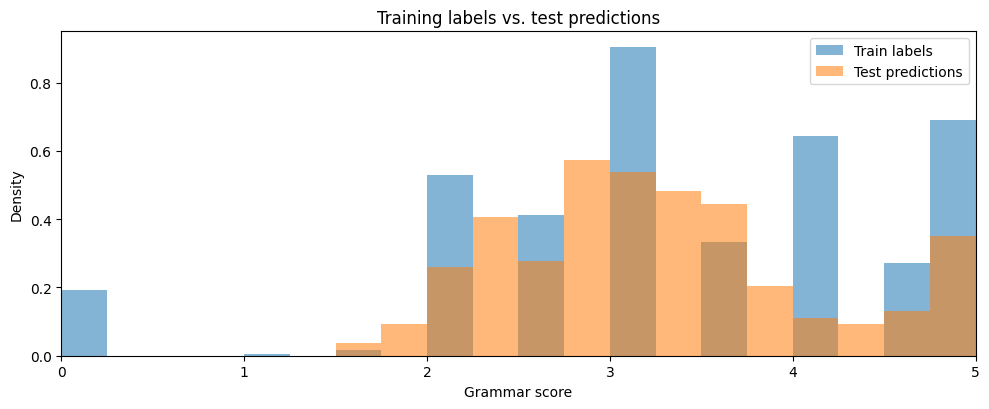

In [48]:
import matplotlib.pyplot as plt
# ---- Final train/test score distribution sanity check ----
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.hist(y, bins=np.linspace(0, 5, 21), density=True, alpha=0.55, label="Train labels")
ax.hist(test_pred, bins=np.linspace(0, 5, 21), density=True, alpha=0.55, label="Test predictions")
ax.set_xlabel("Grammar score")
ax.set_ylabel("Density")
ax.set_xlim(0, 5)
ax.set_title("Training labels vs. test predictions")
ax.legend()
plt.tight_layout()
plt.show()


## 11. Visual Diagnostics and Interpretability

The visual layer is designed to make the modeling choices easy to inspect:

- end-to-end multimodal pipeline diagram
- representative waveform and transcript
- training-score distribution and baseline
- descriptive relationships between interpretable grammar/fluency features and score
- controlled model comparison
- OOF predicted-vs-actual performance and residual behaviour
- stacker weights and error by score level
- final train-vs-test score distribution sanity check

These visuals complement the numerical metrics and help explain both model behaviour and limitations.


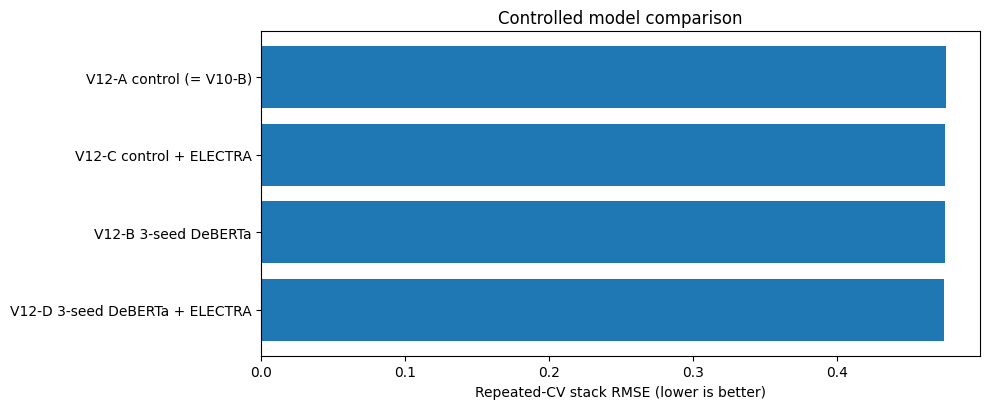

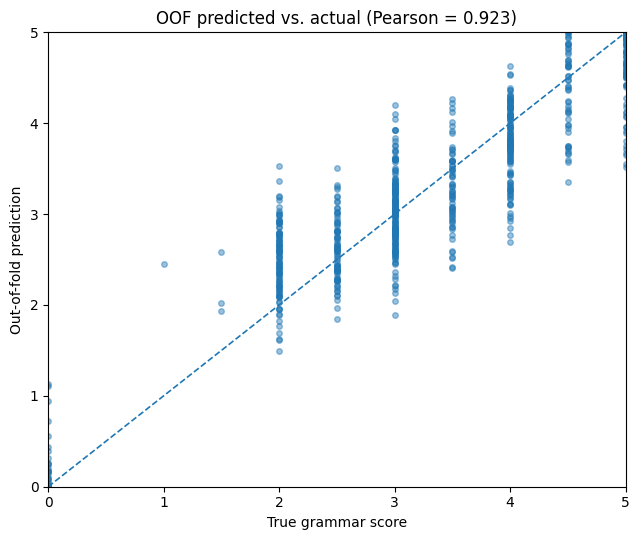

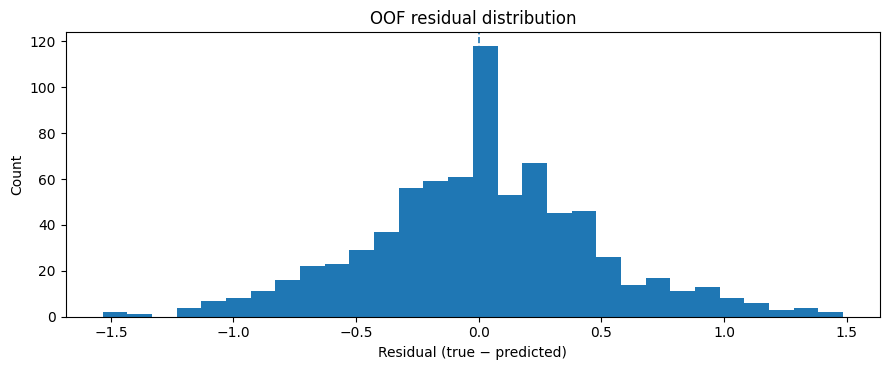

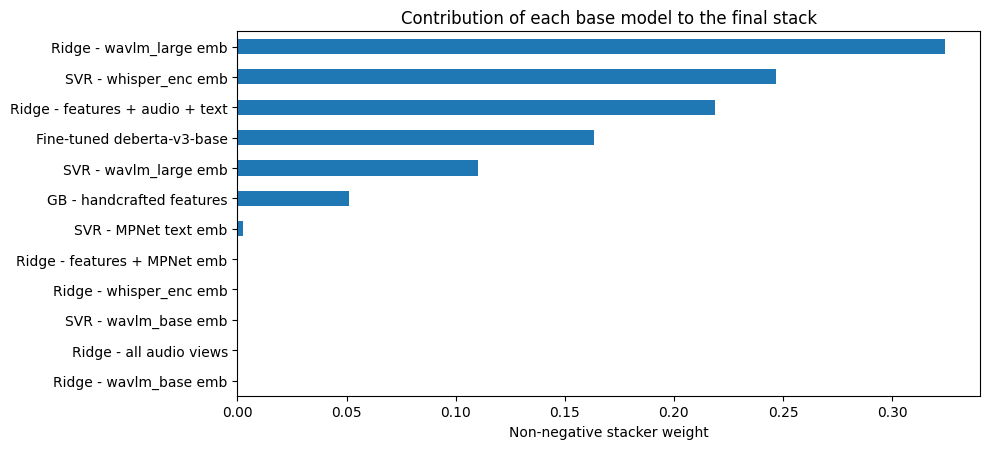

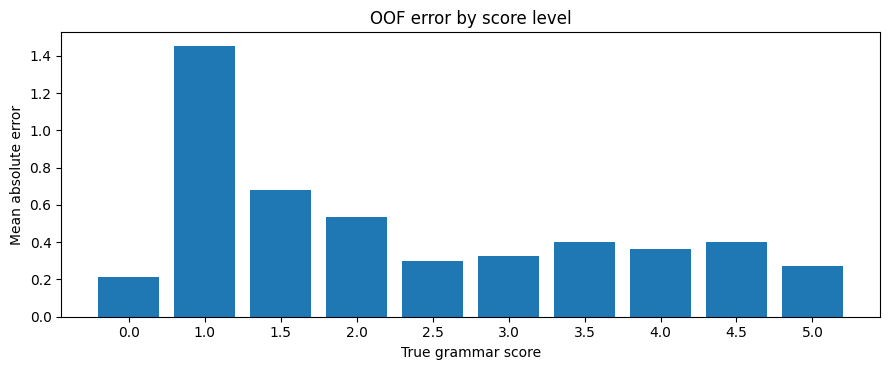

Largest out-of-fold errors:


,filename,true,pred,transcript,abs_err
162,audio_128.wav,2.0,3.53,Staying at a resort is a relaxing and enjoyabl...,1.53
226,audio_357.wav,5.0,3.51,There were slides and monkey bars and swing se...,1.49
423,audio_108.wav,1.0,2.45,As a young child one of the most exciting plac...,1.45
361,audio_555.wav,5.0,3.55,I'm gonna describe the scene of a crowded mark...,1.45
308,audio_321.wav,2.0,3.37,"Well, my favorite hobby, I can say my favorite...",1.37
724,audio_91.wav,5.0,3.65,Imagine a vibrant marketplace in vanilla bustl...,1.35
606,audio_159.wav,5.0,3.67,"Okay, I'm immersing in the melodic tranquility...",1.33
696,audio_107.wav,4.0,2.70,My goal in life is to become a hockey player b...,1.30


In [49]:
import matplotlib.pyplot as plt
# ---- Recruiter-facing model diagnostics ----
vs = variant_scores.sort_values("STACK CV RMSE", ascending=True)

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.barh(vs["variant"], vs["STACK CV RMSE"])
ax.set_xlabel("Repeated-CV stack RMSE (lower is better)")
ax.set_title("Controlled model comparison")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(y, oof_stack, alpha=0.45, s=16)
ax.plot([0, 5], [0, 5], linestyle="--", linewidth=1.2)
ax.set_xlabel("True grammar score")
ax.set_ylabel("Out-of-fold prediction")
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_title(f"OOF predicted vs. actual (Pearson = {CV_PEARSON:.3f})")
plt.tight_layout()
plt.show()

res_ = y - oof_stack
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(res_, bins=30)
ax.axvline(0, linestyle="--", linewidth=1.2)
ax.set_xlabel("Residual (true − predicted)")
ax.set_ylabel("Count")
ax.set_title("OOF residual distribution")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.6))
stack_weights.sort_values().plot.barh(ax=ax)
ax.set_xlabel("Non-negative stacker weight")
ax.set_title("Contribution of each base model to the final stack")
plt.tight_layout()
plt.show()

score_mae = pd.DataFrame({"label": y, "abs_err": np.abs(res_)}) \
    .groupby("label")["abs_err"].mean()

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(score_mae.index.astype(str), score_mae.values)
ax.set_xlabel("True grammar score")
ax.set_ylabel("Mean absolute error")
ax.set_title("OOF error by score level")
plt.tight_layout()
plt.show()

bad = pd.DataFrame({
    "filename": all_df.loc[tr_mask, "filename"].values,
    "true": y,
    "pred": oof_stack.round(2),
    "transcript": all_df.loc[tr_mask, "transcript"].str[:180].values
})
bad["abs_err"] = (bad.true - bad.pred).abs()
print("Largest out-of-fold errors:")
display(bad.sort_values("abs_err", ascending=False).head(8))


## 12. Development Notes

During development, the main findings were consistent:

- **Pretrained audio representations provided the strongest predictive signal.**
- Transcript-based grammar and linguistic features added complementary information.
- Fine-tuned DeBERTa was the most useful supervised text branch.
- More aggressive feature pruning and calibration did not consistently improve the leaderboard.
- Multi-seed fine-tuning provided a small but consistent improvement over a single fine-tuned text model.

These experiments ultimately led to the current multimodal ensemble design.


## 13. Final Report

The final report below is generated directly from the executed notebook and contains the selected configuration, validation metrics, model contributions and submission diagnostics.

**Best observed leaderboard score during development: 0.3668.**

> The leaderboard score and local RMSE are different quantities because the competition uses a hidden evaluation metric. Local CV is therefore used primarily for model comparison, while the leaderboard is used as the final external benchmark.


In [50]:
variant_display = {
    "V12-A control (= V10-B)": "Control",
    "V12-B 3-seed DeBERTa": "3-seed DeBERTa",
    "V12-C control + ELECTRA": "Control + ELECTRA",
    "V12-D 3-seed DeBERTa + ELECTRA": "3-seed DeBERTa + ELECTRA",
}
vtbl = "\n".join(f"| {variant_display.get(r['variant'], r['variant'])} | {r['STACK CV RMSE']:.4f} | {r['STACK CV Pearson']:.4f} | {int(r['n_base_models'])} |" for _, r in variant_scores.iterrows())
mtbl = "\n".join(f"| {r['model']} | {r['group']} | {r['CV RMSE']:.4f} | {r['CV Pearson']:.4f} |" for _, r in model_table.iterrows())
atbl = "\n".join(f"| without {r['stack without group']} | {r['CV RMSE']:.4f} | {r['CV Pearson']:.4f} |" for _, r in abl.iterrows())
wtbl = "\n".join(f"| {n} | {v:.3f} |" for n, v in stack_weights.items())
views = ", ".join(f"{k} ({v.shape[1]} dims)" for k, v in AUDIO_VIEWS.items())
display(Markdown(f'''
### Pipeline
`audio → 16 kHz mono → (a) Whisper-small transcript → {FEATS_ENGINEERED.shape[1]} handcrafted features (text, repetition, audio, GPT-2 perplexity, LanguageTool, spaCy, grammar/syntax/disfluency), MPNet embeddings, fine-tuned transformer(s)  |  (b) audio views: {views} → {len(names)} base models (GB, Ridge, SVR, fine-tuned transformers) on 5-fold CV → non-negative linear stacker → clip to [0, 5]`

### Key results (selected variant: **{variant_display.get(selected, selected)}**)
| Metric | Value |
|---|---|
| **Training RMSE (final ensemble, training clips)** | **{TRAIN_RMSE:.4f}** |
| Training Pearson | {TRAIN_PEARSON:.4f} |
| **CV RMSE (out-of-fold, repeated stack CV)** | **{CV_RMSE:.4f}** (95% bootstrap CI {CI_RMSE[0]:.3f}–{CI_RMSE[1]:.3f}) |
| **CV Pearson** | **{CV_PEARSON:.4f}** (95% bootstrap CI {CI_PEARSON[0]:.3f}–{CI_PEARSON[1]:.3f}) |
| Baseline RMSE (predict the mean) | {BASE_RMSE:.4f} |

*Training RMSE note:* base-model training predictions are averages of the five fold models (each saw 80% of the training clips) passed through the final stacker, so it is a mildly optimistic in-sample figure. The CV numbers are the honest estimate of generalisation.

### Controlled experiment and selection rule
| Stack variant | CV RMSE | CV Pearson | Base models |
|---|---|---|---|
{vtbl}

The selection rule was fixed before evaluation: a challenger must improve RMSE by ≥ 0.002 over the control without reducing Pearson. **Outcome:** {decision}.

### Per-model CV results (selected stack)
| Model | Group | CV RMSE | CV Pearson |
|---|---|---|---|
{mtbl}

### Ablation (what each model group contributes)
| Stack variant | CV RMSE | CV Pearson |
|---|---|---|
{atbl}

### Stacker weights
| Model | Weight |
|---|---|
{wtbl}

intercept = {final_stacker.intercept_:.3f}

### Design decisions
- **Out-of-fold stacking with shared folds**, stack evaluated by separately seeded CV; no test labels or test predictions enter any fitting or selection step.
- **Train and test share file names**, so audio paths and caches are keyed by *(split, filename)*; transcript-dependent caches carry a transcript fingerprint.
- **Audio carries substantial signal**, so three complementary audio encoders are used; the fine-tuned transformer provides the complementary text view.
- **No post-hoc calibration or external blends are included in the final submission.**
- **Pre-registered adoption rule** keeps the model choice conservative when CV differences are very small.

### Limitations and next steps
- Labels are subjective half-point MOS ratings, which sets a noise floor on RMSE; the bootstrap interval is about ±0.026 on CV RMSE.
- ASR normalises some speaker errors, so grammar mistakes can be lost before the text models see them.
- Predictions stay compressed at the extremes (scores 0–1 and 5).
- Further ideas: end-to-end fine-tuning of an audio encoder; stronger temporal modelling of frame-level speech representations.
'''))


### Pipeline
`audio → 16 kHz mono → (a) Whisper-small transcript → 65 handcrafted features (text, repetition, audio, GPT-2 perplexity, LanguageTool, spaCy, grammar/syntax/disfluency), MPNet embeddings, fine-tuned transformer(s)  |  (b) audio views: wavlm_base (4608 dims), whisper_enc (4608 dims), wavlm_large (6144 dims) → 12 base models (GB, Ridge, SVR, fine-tuned transformers) on 5-fold CV → non-negative linear stacker → clip to [0, 5]`

### Key results (selected variant: **Control**)
| Metric | Value |
|---|---|
| **Training RMSE (final ensemble, training clips)** | **0.1892** |
| Training Pearson | 0.9884 |
| **CV RMSE (out-of-fold, repeated stack CV)** | **0.4760** (95% bootstrap CI 0.449–0.502) |
| **CV Pearson** | **0.9235** (95% bootstrap CI 0.910–0.935) |
| Baseline RMSE (predict the mean) | 1.2382 |

*Training RMSE note:* base-model training predictions are averages of the five fold models (each saw 80% of the training clips) passed through the final stacker, so it is a mildly optimistic in-sample figure. The CV numbers are the honest estimate of generalisation.

### Controlled experiment and selection rule
| Stack variant | CV RMSE | CV Pearson | Base models |
|---|---|---|---|
| Control | 0.4760 | 0.9235 | 12 |
| 3-seed DeBERTa | 0.4751 | 0.9238 | 12 |
| Control + ELECTRA | 0.4752 | 0.9237 | 13 |
| 3-seed DeBERTa + ELECTRA | 0.4749 | 0.9239 | 13 |

The selection rule was fixed before evaluation: a challenger must improve RMSE by ≥ 0.002 over the control without reducing Pearson. **Outcome:** control kept: best challenger V12-D 3-seed DeBERTa + ELECTRA reaches 0.4749 vs control 0.4760 (gain 0.0011 < 0.002).

### Per-model CV results (selected stack)
| Model | Group | CV RMSE | CV Pearson |
|---|---|---|---|
| Ridge - wavlm_large emb | audio_wavlm_large | 0.5114 | 0.9109 |
| Ridge - all audio views | audio_combined | 0.5156 | 0.9094 |
| Ridge - features + audio + text | multimodal | 0.5277 | 0.9049 |
| SVR - wavlm_large emb | audio_wavlm_large | 0.5295 | 0.9072 |
| Ridge - whisper_enc emb | audio_whisper_enc | 0.5446 | 0.8988 |
| Ridge - wavlm_base emb | audio_wavlm_base | 0.5469 | 0.8973 |
| SVR - whisper_enc emb | audio_whisper_enc | 0.5478 | 0.9019 |
| SVR - wavlm_base emb | audio_wavlm_base | 0.5511 | 0.8971 |
| Fine-tuned deberta-v3-base | finetune | 0.7798 | 0.7804 |
| GB - handcrafted features | features | 0.8203 | 0.7492 |
| Ridge - features + MPNet emb | text | 0.8717 | 0.7108 |
| SVR - MPNet text emb | text | 0.9848 | 0.6068 |

### Ablation (what each model group contributes)
| Stack variant | CV RMSE | CV Pearson |
|---|---|---|
| without audio_combined | 0.4759 | 0.9235 |
| without audio_wavlm_base | 0.4760 | 0.9235 |
| without audio_wavlm_large | 0.4837 | 0.9209 |
| without audio_whisper_enc | 0.4808 | 0.9218 |
| without features | 0.4765 | 0.9233 |
| without finetune | 0.4851 | 0.9204 |
| without multimodal | 0.4794 | 0.9223 |
| without text | 0.4748 | 0.9239 |

### Stacker weights
| Model | Weight |
|---|---|
| Ridge - wavlm_large emb | 0.324 |
| SVR - whisper_enc emb | 0.247 |
| Ridge - features + audio + text | 0.219 |
| Fine-tuned deberta-v3-base | 0.163 |
| SVR - wavlm_large emb | 0.110 |
| GB - handcrafted features | 0.051 |
| SVR - MPNet text emb | 0.003 |
| Ridge - wavlm_base emb | 0.000 |
| Ridge - whisper_enc emb | 0.000 |
| SVR - wavlm_base emb | 0.000 |
| Ridge - all audio views | 0.000 |
| Ridge - features + MPNet emb | 0.000 |

intercept = -0.384

### Design decisions
- **Out-of-fold stacking with shared folds**, stack evaluated by separately seeded CV; no test labels or test predictions enter any fitting or selection step.
- **Train and test share file names**, so audio paths and caches are keyed by *(split, filename)*; transcript-dependent caches carry a transcript fingerprint.
- **Audio carries substantial signal**, so three complementary audio encoders are used; the fine-tuned transformer provides the complementary text view.
- **No post-hoc calibration or external blends are included in the final submission.**
- **Pre-registered adoption rule** keeps the model choice conservative when CV differences are very small.

### Limitations and next steps
- Labels are subjective half-point MOS ratings, which sets a noise floor on RMSE; the bootstrap interval is about ±0.026 on CV RMSE.
- ASR normalises some speaker errors, so grammar mistakes can be lost before the text models see them.
- Predictions stay compressed at the extremes (scores 0–1 and 5).
- Further ideas: end-to-end fine-tuning of an audio encoder; stronger temporal modelling of frame-level speech representations.
